# Delta-Hedged Options Strategy - Full Pipeline

**Team Members and Student IDs**
- Madhav Fadadu — `madhavf`
- Vidhi Jain — `vidhi`
- Bailey Meche — `baileymeche`
- Utsav Thakur — `utsavthakur`
- Mohamed Zakaria — `mohzak`

---

### Pipeline Overview

| Stage | Description |
|-------|-------------|
| **Stage 1–3** | Raw Data Collection, Point-in-Time Adjustment, Feature Engineering |
| **Stage 4–5** | Daily Feature Panel + LSTM Sequence Construction |
| **Stage 6** | Walk-Forward LSTM Training |
| **Stage 7** | Cross-Sectional Ranking & Signal Construction |
| **Stage 8** | Earnings-Triggered Signal Generation |
| **Stage 9** | Option Selection |
| **Stage 10–11** | Delta Hedge + Daily Rebalancing |
| **Stage 12** | Portfolio P&L Computation |
| **Stage 13** | Performance Evaluation + Risk Framework |



## Project Motivation and Strategy Overview

Our objective is to construct a hypothesis-driven nonlinear forecasting framework grounded in economically interpretable firm-level signals. We study whether delayed interactions between accounting fundamentals and market prices contain short-horizon predictive structure that can be systematically exploited. 

The economic intuition is that new fundamental information is not always incorporated into prices instantly, especially in environments where heterogeneous investor attention and processing speeds lead to gradual information diffusion, and that the adjustment path can depend on prior firm state, recent returns, and cross-feature interactions. 

This motivates modeling returns as a sequence problem rather than a single-period regression where the effect of past information may evolve nonlinearly over time rather than decay at a fixed rate. Classical linear lag structures provide useful baseline intuition, but they impose fixed additive effects and can miss regime-dependent responses. We therefore use an LSTM-based formulation to represent nonlinear, state-dependent lag dynamics while preserving a transparent feature pipeline. The gating mechanism allows the model to dynamically weight historical information conditional on evolving state variables.

The predictive signal in this draft is the model-implied next-step return direction and magnitude from lagged firm-level features and beta-adjusted price context.  At strategy level, the signal maps to relative long/short conviction scores after ranking predicted return strength across the fixed universe. 

The high-level trading intuition is that firms with stronger positive predicted drift receive higher weight, while weaker predicted drift receives lower or negative weight, subject to future risk constraints in the final project stage.

In this draft, we define the predictive target at the daily sampling frequency. However, event-time diagnostics suggest that return responses may persist across multi-week windows. The modeling framework is therefore designed to remain agnostic to horizon choice and can be extended to multi-step or cumulative return targets in the final stage.


---
## Stage 1 — Raw Data Collection

Three datasets are required:
- **Fundamentals (quarterly):** ROE, profit_margin, debt_equity, EPS, book_value_per_share — from Zacks
- **Stock Prices (daily):** date, ticker, open, close, adj_open, adj_close, volume
- **Options Data (daily):** from OptionMetrics IvyDB US — ATM option prices, delta, implied volatility


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd

# Ensure project-root imports when running notebook from notebooks/.
CWD = Path.cwd().resolve()
if (CWD / "team_t").exists():
    TEAM_ROOT = CWD / "team_t"
elif CWD.name == "team_t":
    TEAM_ROOT = CWD
elif CWD.name == "notebooks" and CWD.parent.name == "team_t":
    TEAM_ROOT = CWD.parent
else:
    TEAM_ROOT = next((p for p in [CWD, *CWD.parents] if p.name == "team_t"), None)

if TEAM_ROOT is None:
    raise FileNotFoundError("Could not resolve team_t directory from current working directory")

if str(TEAM_ROOT) not in sys.path:
    sys.path.insert(0, str(TEAM_ROOT))

from src.data_utils import (
    configure_api_from_env,
    fetch_zacks_table,
    load_prices_csv_required,
    build_static_top10_universe,
    prepare_fundamentals_with_availability,
    asof_join_point_in_time,
    validate_point_in_time_panel,
    connect_wrds,
    pull_optionmetrics_calls_atm_dataset,
)
from src.feature_engineering import (
    add_split_adjusted_intraday_prices,
    add_fundamental_change_features,
    add_price_liquidity_features,
    compute_price_to_book,
    compute_rolling_beta_vs_spy,
    winsorize_cross_sectional,
    zscore_cross_sectional,
)


### Parameters and Output Paths

In [2]:
# Full-history defaults for forward-walk workflows.
PRICE_START = pd.Timestamp("1900-01-01")
PRICE_END = pd.Timestamp.today().normalize()
RANK_DATE = pd.Timestamp("2012-12-31")
LAG_DAYS = 45
8
BETA_WINDOW = 252
BETA_MIN_OBS = 126

OPT_START = None
OPT_END = None

# Cache controls for faster reruns.
# Set any of these to True when you need a fresh pull/recompute.
USE_CACHE = True
REFRESH_FUNDAMENTALS = False
REFRESH_PRICES = False
REFRESH_OPTIONS = False
REFRESH_FEATURE_PANEL = False

PRICES_CSV = TEAM_ROOT / "data" / "PRICES.csv"
OUTPUT_DIR = TEAM_ROOT / "data" / "lstm_draft" / "processed"
OPTIONS_DIR = TEAM_ROOT / "data" / "options"
for path in [OUTPUT_DIR, OPTIONS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

UNIVERSE_CSV = OUTPUT_DIR / "lstm_static_top10_universe_2012_12_31.csv"

# Raw exports (full-history canonical)
PRICES_ADJ_PARQUET_FULL = OUTPUT_DIR / "prices_adjusted_full_history.parquet"
FUNDAMENTALS_PARQUET_FULL = OUTPUT_DIR / "fundamentals_with_availability_full_history.parquet"
BETA_PARQUET_FULL = OUTPUT_DIR / "beta_252d_full_history.parquet"
OPTIONS_PARQUET_FULL = OPTIONS_DIR / "optionmetrics_calls_atm_20_60d_full_history.parquet"

# Raw exports (legacy names)
PRICES_ADJ_PARQUET = OUTPUT_DIR / "prices_adjusted_2006_2013.parquet"
FUNDAMENTALS_PARQUET = OUTPUT_DIR / "fundamentals_with_availability_2006_2013.parquet"
BETA_PARQUET = OUTPUT_DIR / "beta_252d_2006_2013.parquet"
OPTIONS_PARQUET = OPTIONS_DIR / "optionmetrics_calls_atm_20_60d_2006_2013.parquet"

# Feature panel exports
FEATURE_PANEL_PARQUET = OUTPUT_DIR / "feature_panel_pit_normalized_full_history.parquet"
FEATURE_PANEL_CSV = OUTPUT_DIR / "feature_panel_pit_normalized_full_history.csv"

# Backward-compatible panel names consumed in older flows.
PANEL_PARQUET_FULL = OUTPUT_DIR / "lstm_feature_panel_full_history.parquet"
PANEL_CSV_FULL = OUTPUT_DIR / "lstm_feature_panel_full_history.csv"
PANEL_PARQUET = OUTPUT_DIR / "lstm_feature_panel_2006_2013.parquet"
PANEL_CSV = OUTPUT_DIR / "lstm_feature_panel_2006_2013.csv"


### Credentials Setup

In [3]:
import nasdaqdatalink

In [4]:
env_candidates = [
    TEAM_ROOT / ".env",
    TEAM_ROOT.parent / ".env",
    Path.cwd() / ".env",
]
configure_api_from_env(env_candidates)


## Fundamentals (quarterly)

Used to construct the signal.

Examples:
- ROE
- profit_margin
- debt_equity
- EPS
- book_value_per_share

These come from Zacks or similar sources.


In [5]:
mt_cols = ["ticker", "sp500_member_flag"]
mktv_cols = ["ticker", "per_end_date", "per_type", "mkt_val"]
fr_cols = [
    "ticker", "per_end_date", "per_type",
    "tot_debt_tot_equity", "ret_equity", "profit_margin", "book_val_per_share",
]
fc_cols = ["ticker", "per_end_date", "per_type", "diluted_net_eps"]

if (
    USE_CACHE
    and not REFRESH_FUNDAMENTALS
    and UNIVERSE_CSV.exists()
    and FUNDAMENTALS_PARQUET_FULL.exists()
):
    top10 = pd.read_csv(UNIVERSE_CSV)
    fundamentals = pd.read_parquet(FUNDAMENTALS_PARQUET_FULL)
    static_tickers = top10["ticker_price"].astype(str).tolist()
    if "ticker" in top10.columns:
        raw_tickers = sorted(top10["ticker"].astype(str).tolist())
    else:
        raw_tickers = sorted(top10["ticker_price"].astype(str).tolist())

    if "per_end_date" in fundamentals.columns:
        fundamentals["per_end_date"] = pd.to_datetime(fundamentals["per_end_date"], errors="coerce")
    if "feature_available_date" in fundamentals.columns:
        fundamentals["feature_available_date"] = pd.to_datetime(
            fundamentals["feature_available_date"], errors="coerce"
        )

    print(f"[cache hit] fundamentals={FUNDAMENTALS_PARQUET_FULL}")
    print(f"[cache hit] universe={UNIVERSE_CSV}")
else:
    mt = fetch_zacks_table("ZACKS/MT", mt_cols, filters={"sp500_member_flag": "Y"}, paginate=True)
    mktv = fetch_zacks_table(
        "ZACKS/MKTV",
        mktv_cols,
        filters={"per_end_date": str(RANK_DATE.date())},
        paginate=True,
    )

    top10 = build_static_top10_universe(mt_df=mt, mktv_df=mktv, rank_date=str(RANK_DATE.date()))
    static_tickers = top10["ticker_price"].tolist()
    raw_tickers = sorted(top10["ticker"].tolist())

    date_lo = PRICE_START.date().isoformat()
    date_hi = PRICE_END.date().isoformat()

    fr = fetch_zacks_table(
        "ZACKS/FR",
        fr_cols,
        filters={"ticker": {"in": raw_tickers}, "per_end_date": {"between": (date_lo, date_hi)}},
        paginate=True,
    )
    fc = fetch_zacks_table(
        "ZACKS/FC",
        fc_cols,
        filters={"ticker": {"in": raw_tickers}, "per_end_date": {"between": (date_lo, date_hi)}},
        paginate=True,
    )
    fundamentals = prepare_fundamentals_with_availability(fr, fc, lag_days=LAG_DAYS)

print(f"[universe] tickers={len(static_tickers)} sample={static_tickers[:5]}")
print(f"[fundamentals] rows={len(fundamentals):,} tickers={fundamentals['ticker_price'].nunique():,}")
print(f"[fundamentals] per_end_date min={fundamentals['per_end_date'].min()} max={fundamentals['per_end_date'].max()}")


[cache hit] fundamentals=/Users/vidhi/Desktop/team_t/data/lstm_draft/processed/fundamentals_with_availability_full_history.parquet
[cache hit] universe=/Users/vidhi/Desktop/team_t/data/lstm_draft/processed/lstm_static_top10_universe_2012_12_31.csv
[universe] tickers=10 sample=['AAPL', 'XOM', 'GOOGL', 'WMT', 'MSFT']
[fundamentals] rows=801 tickers=10
[fundamentals] per_end_date min=2006-01-31 00:00:00 max=2026-01-31 00:00:00


## Stock Prices (daily)

Required for:
- return targets
- delta hedge
- realized volatility

Fields:
- date
- ticker
- open
- close
- adj_open
- adj_close
- volume


In [6]:
price_cols = ["ticker", "date", "open", "close", "adj_close", "volume"]
price_tickers = sorted(set(static_tickers + ["SPY"]))

if USE_CACHE and not REFRESH_PRICES and PRICES_ADJ_PARQUET_FULL.exists():
    prices_adj = pd.read_parquet(PRICES_ADJ_PARQUET_FULL)
    prices_adj["date"] = pd.to_datetime(prices_adj["date"], errors="coerce")
    print(f"[cache hit] prices_adj={PRICES_ADJ_PARQUET_FULL}")
else:
    prices = load_prices_csv_required(
        csv_path=PRICES_CSV,
        tickers=price_tickers,
        start=PRICE_START.date().isoformat(),
        end=PRICE_END.date().isoformat(),
        usecols=price_cols,
    )
    prices_adj = add_split_adjusted_intraday_prices(prices)

if prices_adj.empty:
    raise ValueError("No price rows returned for selected ticker universe and date range.")

print(f"[prices_adj] rows={len(prices_adj):,} tickers={prices_adj['ticker'].nunique():,}")
print(f"[prices_adj] date_min={prices_adj['date'].min()} date_max={prices_adj['date'].max()}")
prices_adj[["date", "ticker", "open", "close", "adj_open", "adj_close", "volume"]].head(3)


[cache hit] prices_adj=/Users/vidhi/Desktop/team_t/data/lstm_draft/processed/prices_adjusted_full_history.parquet
[prices_adj] rows=127,368 tickers=11
[prices_adj] date_min=1962-01-02 00:00:00 date_max=2024-11-05 00:00:00


,date,ticker,open,close,adj_open,adj_close,volume
0,1980-12-12,AAPL,28.75,28.75,0.099192,0.099192,2093900.0
1,1980-12-15,AAPL,27.38,27.25,0.094466,0.094017,785200.0
2,1980-12-16,AAPL,25.37,25.25,0.087531,0.087117,472000.0


### Export Raw Fundamentals + Prices


In [7]:
top10.to_csv(UNIVERSE_CSV, index=False)
fundamentals.to_parquet(FUNDAMENTALS_PARQUET_FULL, index=False)
prices_adj.to_parquet(PRICES_ADJ_PARQUET_FULL, index=False)

# Backward-compatible raw filenames
fundamentals.to_parquet(FUNDAMENTALS_PARQUET, index=False)
prices_adj.to_parquet(PRICES_ADJ_PARQUET, index=False)

print(f"[export] universe={UNIVERSE_CSV}")
print(f"[export] fundamentals_full={FUNDAMENTALS_PARQUET_FULL}")
print(f"[export] prices_adj_full={PRICES_ADJ_PARQUET_FULL}")


[export] universe=/Users/vidhi/Desktop/team_t/data/lstm_draft/processed/lstm_static_top10_universe_2012_12_31.csv
[export] fundamentals_full=/Users/vidhi/Desktop/team_t/data/lstm_draft/processed/fundamentals_with_availability_full_history.parquet
[export] prices_adj_full=/Users/vidhi/Desktop/team_t/data/lstm_draft/processed/prices_adjusted_full_history.parquet


## Options Data (daily)

From OptionMetrics IvyDB US.

Used for:
- ATM option prices
- delta
- implied volatility

Example fields:
- date
- ticker
- strike
- expiration
- delta
- mid_price
- implied_vol
- open_interest


In [8]:
opt_start_date = OPT_START if OPT_START is not None else prices_adj["date"].min().date().isoformat()
print(f"[options pull window] start={opt_start_date} end={OPT_END if OPT_END is not None else 'latest available'}")

use_options_cache = USE_CACHE and not REFRESH_OPTIONS and OPTIONS_PARQUET_FULL.exists()
options_df = None

if use_options_cache:
    cached = pd.read_parquet(OPTIONS_PARQUET_FULL)
    dte_ok = ("dte" in cached.columns) and cached["dte"].between(30, 60).all()
    cp_ok = ("cp_flag" in cached.columns) and cached["cp_flag"].astype(str).str.upper().eq("C").all()
    if dte_ok and cp_ok:
        options_df = cached
        print(f"[cache hit] options={OPTIONS_PARQUET_FULL}")
        print(f"[cache hit] rows={len(options_df):,} tickers={options_df['ticker'].nunique():,}")
    else:
        print("[cache stale] options cache does not satisfy current rules (calls-only, DTE 30-60). Re-pulling.")

if options_df is None:
    db = connect_wrds()
    try:
        options_df = pull_optionmetrics_calls_atm_dataset(
            db=db,
            universe_path=UNIVERSE_CSV,
            fallback_universe_path=UNIVERSE_CSV,
            output_path=OPTIONS_PARQUET_FULL,
            start_date=opt_start_date,
            end_date=OPT_END,
        )
    finally:
        db.close()
        print("[db] WRDS connection closed")

if OPTIONS_PARQUET_FULL.exists() and OPTIONS_PARQUET_FULL != OPTIONS_PARQUET:
    options_df.to_parquet(OPTIONS_PARQUET, index=False)

print(f"[options] rows={len(options_df):,} tickers={options_df['ticker'].nunique():,}")
print(f"[options] output_full={OPTIONS_PARQUET_FULL}")
print(f"[options] output_legacy={OPTIONS_PARQUET}")


[options pull window] start=1962-01-02 end=latest available
[cache hit] options=/Users/vidhi/Desktop/team_t/data/options/optionmetrics_calls_atm_20_60d_full_history.parquet
[cache hit] rows=62,971 tickers=9
[options] rows=62,971 tickers=9
[options] output_full=/Users/vidhi/Desktop/team_t/data/options/optionmetrics_calls_atm_20_60d_full_history.parquet
[options] output_legacy=/Users/vidhi/Desktop/team_t/data/options/optionmetrics_calls_atm_20_60d_2006_2013.parquet


---
## Stage 2 — Point-in-Time Adjustment

Align fundamentals with the date they become observable to investors.

```
availability_date = period_end + reporting_lag  (typical lag = 45 days)
```

This ensures the model only sees information known at time *t* and eliminates look-ahead bias.

## Stage 3 — Feature Engineering

Transform fundamentals into predictive signals by computing changes rather than levels:
- `roe_change`, `margin_change`, `leverage_change`, `eps_growth`, `book_value_growth`
- `log_return`, `rolling_beta`, `volume_ratio`

Apply cross-sectional winsorization (1–99%) and z-score normalization.


In [9]:
if USE_CACHE and not REFRESH_FEATURE_PANEL and FEATURE_PANEL_PARQUET.exists() and BETA_PARQUET_FULL.exists():
    panel_out = pd.read_parquet(FEATURE_PANEL_PARQUET)
    beta_df = pd.read_parquet(BETA_PARQUET_FULL)
    panel_out["date"] = pd.to_datetime(panel_out["date"], errors="coerce")

    feature_cols = [
        "roe_change",
        "margin_change",
        "leverage_change",
        "eps_growth",
        "book_value_growth",
        "log_return",
        "rolling_beta",
        "volume_ratio",
    ]
    feature_cols = [col for col in feature_cols if col in panel_out.columns]
    print(f"[cache hit] feature_panel={FEATURE_PANEL_PARQUET}")
else:
    fund_pti = fundamentals.copy()
    fund_pti["ticker"] = fund_pti["ticker_price"].astype(str).str.upper().str.strip()

    prices_model = prices_adj[prices_adj["ticker"].isin(static_tickers)].copy()
    prices_model["ticker"] = prices_model["ticker"].astype(str).str.upper().str.strip()
    panel = asof_join_point_in_time(
        prices_df=prices_model,
        fundamentals_df=fund_pti,
        on_date_col="date",
        by_ticker_col="ticker",
    )
    validate_point_in_time_panel(panel)

    panel_feat = panel.sort_values(["ticker", "date"]).reset_index(drop=True)
    panel_feat = compute_price_to_book(panel_feat)

    # Step-3 features: fundamentals as changes/growth plus price/liquidity terms.
    panel_feat = add_fundamental_change_features(panel_feat, ticker_col="ticker", date_col="date")
    panel_feat = add_price_liquidity_features(
        panel_feat,
        ticker_col="ticker",
        date_col="date",
        price_col="adj_close",
        volume_col="volume",
        volume_window=20,
        min_volume_obs=5,
    )

    beta_df = compute_rolling_beta_vs_spy(
        prices_df=prices_adj[["ticker", "date", "adj_close"]].copy(),
        window=BETA_WINDOW,
        min_obs=BETA_MIN_OBS,
    )
    panel_feat = panel_feat.merge(beta_df[["ticker", "date", "beta_252d"]], on=["ticker", "date"], how="left")
    panel_feat = panel_feat.rename(columns={"beta_252d": "rolling_beta"})

    feature_cols = [
        "roe_change",
        "margin_change",
        "leverage_change",
        "eps_growth",
        "book_value_growth",
        "log_return",
        "rolling_beta",
        "volume_ratio",
    ]
    feature_cols = [col for col in feature_cols if col in panel_feat.columns]

    panel_feat = winsorize_cross_sectional(
        panel_df=panel_feat,
        feature_cols=feature_cols,
        date_col="date",
        lower_q=0.01,
        upper_q=0.99,
    )
    panel_feat = zscore_cross_sectional(
        panel_df=panel_feat,
        feature_cols=feature_cols,
        date_col="date",
        suffix="_z",
    )

    # Keep backward-compatible next-day target alongside engineered features.
    panel_feat["adj_close"] = pd.to_numeric(panel_feat["adj_close"], errors="coerce")
    panel_feat.loc[panel_feat["adj_close"] <= 0, "adj_close"] = np.nan
    panel_feat["target_next_log_ret"] = panel_feat.groupby("ticker")["adj_close"].transform(
        lambda s: np.log(s.shift(-1)) - np.log(s)
    )

    panel_out = panel_feat.sort_values(["ticker", "date"]).reset_index(drop=True)

panel_out = panel_out.sort_values(["ticker", "date"]).reset_index(drop=True)
duplicates = int(panel_out.duplicated(["ticker", "date"]).sum())
assert duplicates == 0, f"Found {duplicates} duplicate (ticker, date) rows in panel_out"

# Export engineered feature panel.
panel_out.to_parquet(FEATURE_PANEL_PARQUET, index=False)
panel_out.to_csv(FEATURE_PANEL_CSV, index=False)

# Backward-compatible panel exports.
panel_out.to_parquet(PANEL_PARQUET_FULL, index=False)
panel_out.to_csv(PANEL_CSV_FULL, index=False)
panel_out.to_parquet(PANEL_PARQUET, index=False)
panel_out.to_csv(PANEL_CSV, index=False)

# Export beta artifacts retained from previous raw-data workflow.
beta_df.to_parquet(BETA_PARQUET_FULL, index=False)
beta_df.to_parquet(BETA_PARQUET, index=False)

print(f"[panel] rows={len(panel_out):,} tickers={panel_out['ticker'].nunique():,}")
print(f"[panel] date_min={panel_out['date'].min()} date_max={panel_out['date'].max()}")
print(f"[panel] feature_cols={feature_cols}")
print(f"[export] feature_panel_parquet={FEATURE_PANEL_PARQUET}")
print(f"[export] feature_panel_csv={FEATURE_PANEL_CSV}")
print(f"[export] beta_full={BETA_PARQUET_FULL}")


[cache hit] feature_panel=/Users/vidhi/Desktop/team_t/data/lstm_draft/processed/feature_panel_pit_normalized_full_history.parquet
[panel] rows=119,368 tickers=10
[panel] date_min=1962-01-02 00:00:00 date_max=2024-11-05 00:00:00
[panel] feature_cols=['roe_change', 'margin_change', 'leverage_change', 'eps_growth', 'book_value_growth', 'log_return', 'rolling_beta', 'volume_ratio']
[export] feature_panel_parquet=/Users/vidhi/Desktop/team_t/data/lstm_draft/processed/feature_panel_pit_normalized_full_history.parquet
[export] feature_panel_csv=/Users/vidhi/Desktop/team_t/data/lstm_draft/processed/feature_panel_pit_normalized_full_history.csv
[export] beta_full=/Users/vidhi/Desktop/team_t/data/lstm_draft/processed/beta_252d_full_history.parquet


---
### Data Coverage and Integrity Validation


In [10]:
def _date_min_max(df: pd.DataFrame, date_col: str) -> tuple[str | None, str | None]:
    if df is None or df.empty or date_col not in df.columns:
        return None, None
    d = pd.to_datetime(df[date_col], errors="coerce")
    return (
        str(d.min().date()) if d.notna().any() else None,
        str(d.max().date()) if d.notna().any() else None,
    )

_fund_df = fundamentals if "fundamentals" in globals() else pd.read_parquet(FUNDAMENTALS_PARQUET_FULL)
_prices_df = prices_adj if "prices_adj" in globals() else pd.read_parquet(PRICES_ADJ_PARQUET_FULL)
_opt_df = options_df if "options_df" in globals() else pd.read_parquet(OPTIONS_PARQUET_FULL)
_panel_df = panel_out if "panel_out" in globals() else pd.read_parquet(FEATURE_PANEL_PARQUET)

coverage = pd.DataFrame(
    [
        {
            "dataset": "Fundamentals (quarterly)",
            "date_field": "per_end_date",
            "date_min": _date_min_max(_fund_df, "per_end_date")[0],
            "date_max": _date_min_max(_fund_df, "per_end_date")[1],
            "rows": int(len(_fund_df)),
            "tickers": int(_fund_df["ticker_price"].nunique()) if "ticker_price" in _fund_df.columns else None,
        },
        {
            "dataset": "Fundamentals availability (PIT)",
            "date_field": "feature_available_date",
            "date_min": _date_min_max(_fund_df, "feature_available_date")[0],
            "date_max": _date_min_max(_fund_df, "feature_available_date")[1],
            "rows": int(len(_fund_df)),
            "tickers": int(_fund_df["ticker_price"].nunique()) if "ticker_price" in _fund_df.columns else None,
        },
        {
            "dataset": "Stock Prices (daily)",
            "date_field": "date",
            "date_min": _date_min_max(_prices_df, "date")[0],
            "date_max": _date_min_max(_prices_df, "date")[1],
            "rows": int(len(_prices_df)),
            "tickers": int(_prices_df["ticker"].nunique()) if "ticker" in _prices_df.columns else None,
        },
        {
            "dataset": "Options Data (daily)",
            "date_field": "date",
            "date_min": _date_min_max(_opt_df, "date")[0],
            "date_max": _date_min_max(_opt_df, "date")[1],
            "rows": int(len(_opt_df)),
            "tickers": int(_opt_df["ticker"].nunique()) if "ticker" in _opt_df.columns else None,
        },
        {
            "dataset": "PIT Feature Panel (daily)",
            "date_field": "date",
            "date_min": _date_min_max(_panel_df, "date")[0],
            "date_max": _date_min_max(_panel_df, "date")[1],
            "rows": int(len(_panel_df)),
            "tickers": int(_panel_df["ticker"].nunique()) if "ticker" in _panel_df.columns else None,
        },
    ]
)
coverage


,dataset,date_field,date_min,date_max,rows,tickers
0,Fundamentals (quarterly),per_end_date,2006-01-31,2026-01-31,801,10
1,Fundamentals availability (PIT),feature_available_date,2006-03-17,2026-03-17,801,10
2,Stock Prices (daily),date,1962-01-02,2024-11-05,127368,11
3,Options Data (daily),date,1996-01-04,2025-08-29,62971,9
4,PIT Feature Panel (daily),date,1962-01-02,2024-11-05,119368,10


In [11]:
# Validate required raw-data blocks and expected fields.
_fund_df = fundamentals if "fundamentals" in globals() else pd.read_parquet(FUNDAMENTALS_PARQUET_FULL)
_prices_df = prices_adj if "prices_adj" in globals() else pd.read_parquet(PRICES_ADJ_PARQUET_FULL)
_opt_df = options_df if "options_df" in globals() else pd.read_parquet(OPTIONS_PARQUET_FULL)
_panel_df = panel_out if "panel_out" in globals() else pd.read_parquet(FEATURE_PANEL_PARQUET)

required_fund = {
    "ROE": ["ret_equity", "roe"],
    "profit_margin": ["profit_margin"],
    "debt_equity": ["tot_debt_tot_equity", "debt_equity"],
    "EPS": ["diluted_net_eps", "eps", "eps_basic"],
    "book_value_per_share": ["book_val_per_share", "book_value_per_share"],
}
required_prices = {
    "date": ["date"],
    "ticker": ["ticker"],
    "open": ["open"],
    "close": ["close"],
    "adj_open": ["adj_open"],
    "adj_close": ["adj_close", "adj_close_intraday"],
    "volume": ["volume"],
}
required_options = {
    "date": ["date"],
    "ticker": ["ticker"],
    "strike": ["strike_price", "strike"],
    "expiration": ["exdate", "expiration"],
    "delta": ["delta"],
    "mid_price": ["mid_price"],
    "implied_vol": ["implied_vol", "implied_volatility", "impl_volatility"],
    "open_interest": ["open_interest"],
}
required_panel = {
    "date": ["date"],
    "ticker": ["ticker"],
    "roe_change": ["roe_change"],
    "margin_change": ["margin_change"],
    "leverage_change": ["leverage_change"],
    "eps_growth": ["eps_growth"],
    "book_value_growth": ["book_value_growth"],
    "log_return": ["log_return"],
    "rolling_beta": ["rolling_beta"],
    "volume_ratio": ["volume_ratio"],
}

def _present(requirements: dict[str, list[str]], cols: list[str]) -> dict[str, str | None]:
    colset = set(cols)
    out: dict[str, str | None] = {}
    for logical, aliases in requirements.items():
        out[logical] = next((a for a in aliases if a in colset), None)
    return out

def _status(mapping: dict[str, str | None]) -> str:
    return "PASS" if all(v is not None for v in mapping.values()) else "FAIL"

rows = [
    {
        "dataset": "Fundamentals (quarterly)",
        "status": _status(_present(required_fund, list(_fund_df.columns))),
    },
    {
        "dataset": "Stock Prices (daily)",
        "status": _status(_present(required_prices, list(_prices_df.columns))),
    },
    {
        "dataset": "Options Data (daily)",
        "status": _status(_present(required_options, list(_opt_df.columns))),
    },
    {
        "dataset": "PIT Feature Panel (daily)",
        "status": _status(_present(required_panel, list(_panel_df.columns))),
    },
]
validation_table = pd.DataFrame(rows)

if (validation_table["status"] == "FAIL").any():
    raise AssertionError("Validation failed:\n" + validation_table.to_string(index=False))

validation_table


,dataset,status
0,Fundamentals (quarterly),PASS
1,Stock Prices (daily),PASS
2,Options Data (daily),PASS
3,PIT Feature Panel (daily),PASS


In [12]:
# Final artifact integrity check.
required_files = [
    UNIVERSE_CSV,
    FUNDAMENTALS_PARQUET_FULL,
    PRICES_ADJ_PARQUET_FULL,
    BETA_PARQUET_FULL,
    OPTIONS_PARQUET_FULL,
    FEATURE_PANEL_PARQUET,
    FEATURE_PANEL_CSV,
]
missing_files = [str(path) for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(f"Missing required exported files: {missing_files}")

opt_chk = pd.read_parquet(OPTIONS_PARQUET_FULL)
required_option_cols = {
    "date", "ticker", "secid", "cp_flag", "strike_price", "exdate", "dte",
    "best_bid", "best_offer", "mid_price", "implied_vol", "delta",
    "underlying_price", "moneyness", "option_mid_return",
}
missing_option_cols = sorted(required_option_cols - set(opt_chk.columns))
if missing_option_cols:
    raise KeyError(f"Options missing columns: {missing_option_cols}")

checks = {}
if not opt_chk.empty:
    checks["calls_only"] = bool(opt_chk["cp_flag"].astype(str).str.upper().eq("C").all())
    checks["dte_30_60"] = bool(opt_chk["dte"].between(30, 60).all())
    checks["positive_bid"] = bool((opt_chk["best_bid"] > 0).all())
    checks["positive_offer"] = bool((opt_chk["best_offer"] > 0).all())
    checks["moneyness_band"] = bool(opt_chk["moneyness"].between(0.95, 1.05).all())
    checks["one_contract_per_ticker_date"] = bool(not opt_chk.duplicated(["ticker", "date"]).any())
    if "open_interest" in opt_chk.columns and opt_chk["open_interest"].notna().any():
        checks["positive_open_interest"] = bool((opt_chk["open_interest"] > 0).all())

integrity_manifest = {
    "fundamentals_rows": int(len(pd.read_parquet(FUNDAMENTALS_PARQUET_FULL))),
    "prices_rows": int(len(pd.read_parquet(PRICES_ADJ_PARQUET_FULL))),
    "options_rows": int(len(opt_chk)),
    "feature_panel_rows": int(len(pd.read_parquet(FEATURE_PANEL_PARQUET))),
    "checks": checks,
}
integrity_manifest


{'fundamentals_rows': 801,
 'prices_rows': 127368,
 'options_rows': 62971,
 'feature_panel_rows': 119368,
 'checks': {'calls_only': True,
  'dte_30_60': True,
  'positive_bid': True,
  'positive_offer': True,
  'moneyness_band': True,
  'one_contract_per_ticker_date': True,
  'positive_open_interest': True}}

---
## Stage 4 - Daily Feature Panel

Construct the final modeling dataset with structure:
`date, ticker, feature_1 … feature_k, target_return`

Target variable: `target_{i,t} = log(P_{i,t+1} / P_{i,t})`

This panel becomes the input for the LSTM.


In [13]:
from __future__ import annotations

from pathlib import Path
import pickle
import sys

import numpy as np
import pandas as pd

# Resolve team_t root regardless of where notebook is launched from.
CWD = Path.cwd().resolve()
if (CWD / "team_t").exists():
    TEAM_ROOT = CWD / "team_t"
elif CWD.name == "team_t":
    TEAM_ROOT = CWD
elif CWD.name == "notebooks" and CWD.parent.name == "team_t":
    TEAM_ROOT = CWD.parent
else:
    TEAM_ROOT = next((p for p in [CWD, *CWD.parents] if p.name == "team_t"), None)

if TEAM_ROOT is None:
    raise FileNotFoundError("Could not resolve team_t directory from current working directory")

if str(TEAM_ROOT) not in sys.path:
    sys.path.insert(0, str(TEAM_ROOT))

from src.feature_engineering import build_lstm_tensors


### Parameters and Paths

In [14]:
LOOKBACK = 60
FORWARD_MIN_TRAIN_YEARS = 5
FORWARD_VALID_YEARS = 1
FORWARD_TEST_YEARS = 1

USE_ZSCORE_FEATURES = True

OUTPUT_DIR = TEAM_ROOT / "data" / "lstm_draft" / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PIT_PANEL_CANDIDATES = [
    OUTPUT_DIR / "feature_panel_pit_normalized_full_history.parquet",
    OUTPUT_DIR / "lstm_feature_panel_full_history.parquet",
]

MODEL_PANEL_PARQUET = OUTPUT_DIR / "lstm_model_panel_full_history.parquet"
MODEL_PANEL_CSV = OUTPUT_DIR / "lstm_model_panel_full_history.csv"

FORWARD_WALK_TENSORS_PKL = OUTPUT_DIR / f"lstm_forward_walk_tensors_lookback_{LOOKBACK}.pkl"
FORWARD_WALK_SUMMARY_CSV = OUTPUT_DIR / f"lstm_forward_walk_tensors_lookback_{LOOKBACK}_summary.csv"

print(f"TEAM_ROOT={TEAM_ROOT}")
print(f"OUTPUT_DIR={OUTPUT_DIR}")


TEAM_ROOT=/Users/vidhi/Desktop/team_t
OUTPUT_DIR=/Users/vidhi/Desktop/team_t/data/lstm_draft/processed


## 2) Load PIT Feature Panel

Loads the first existing candidate file and reports coverage.

In [15]:
pit_source = next((p for p in PIT_PANEL_CANDIDATES if p.exists()), None)
if pit_source is None:
    checked = "\n".join(str(p) for p in PIT_PANEL_CANDIDATES)
    raise FileNotFoundError(f"No PIT panel found. Checked:\n{checked}")

panel = pd.read_parquet(pit_source)
if "date" not in panel.columns or "ticker" not in panel.columns:
    raise KeyError("PIT panel must contain 'date' and 'ticker' columns")

panel["date"] = pd.to_datetime(panel["date"], errors="coerce")
panel["ticker"] = panel["ticker"].astype(str).str.upper().str.strip()
panel = panel.dropna(subset=["date", "ticker"]).sort_values(["ticker", "date"]).reset_index(drop=True)

print(f"[pit source] {pit_source}")
print(f"[pit panel] rows={len(panel):,} tickers={panel['ticker'].nunique():,}")
print(f"[pit panel] date_min={panel['date'].min()} date_max={panel['date'].max()}")
panel.head(3)


[pit source] /Users/vidhi/Desktop/team_t/data/lstm_draft/processed/feature_panel_pit_normalized_full_history.parquet
[pit panel] rows=119,368 tickers=10
[pit panel] date_min=1962-01-02 00:00:00 date_max=2024-11-05 00:00:00


,ticker,date,open,close,volume,adj_close,adj_factor,adj_open,adj_close_intraday,per_end_date,...,rolling_beta,roe_change_z,margin_change_z,leverage_change_z,eps_growth_z,book_value_growth_z,log_return_z,rolling_beta_z,volume_ratio_z,target_next_log_ret
0,AAPL,1980-12-12,28.75,28.75,2093900.0,0.099192,0.00345,0.099192,0.099192,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.053584
1,AAPL,1980-12-15,27.38,27.25,785200.0,0.094017,0.00345,0.094466,0.094017,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,-2.178756,NaN,NaN,-0.076227
2,AAPL,1980-12-16,25.37,25.25,472000.0,0.087117,0.00345,0.087531,0.087117,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,-2.129674,NaN,NaN,0.024258


## 3) Step 4: Build Daily Modeling Panel

Target definition:

`target_return = log(P_{t+1} / P_t)` grouped by ticker, using `adj_close`.

Feature selection:

- Uses z-scored PIT features when present (`*_z`)
- Falls back to raw features if z-scored columns are missing

In [16]:
if "adj_close" not in panel.columns:
    raise KeyError("Expected 'adj_close' in PIT panel to build target_return")

panel_model = panel.copy()
panel_model["adj_close"] = pd.to_numeric(panel_model["adj_close"], errors="coerce")
panel_model.loc[panel_model["adj_close"] <= 0, "adj_close"] = np.nan

panel_model["target_return"] = panel_model.groupby("ticker")["adj_close"].transform(
    lambda s: np.log(s.shift(-1)) - np.log(s)
)

base_feature_candidates = [
    "roe_change",
    "margin_change",
    "leverage_change",
    "eps_growth",
    "book_value_growth",
    "log_return",
    "rolling_beta",
    "volume_ratio",
]
z_feature_candidates = [f"{c}_z" for c in base_feature_candidates]
legacy_feature_candidates = [
    "adj_close",
    "volume",
    "tot_debt_tot_equity",
    "ret_equity",
    "profit_margin",
    "book_val_per_share",
    "diluted_net_eps",
    "price_to_book",
    "beta_252d",
]

def _complete_row_count(df: pd.DataFrame, cols: list[str]) -> int:
    if not cols:
        return 0
    return int(df[cols].notna().all(axis=1).sum())

def _max_ticker_year_rows(df: pd.DataFrame, cols: list[str]) -> int:
    if not cols:
        return 0
    valid = df[cols + ["target_return"]].notna().all(axis=1)
    if not bool(valid.any()):
        return 0
    tmp = df.loc[valid, ["ticker", "date"]].copy()
    tmp["year"] = tmp["date"].dt.year
    counts = tmp.groupby(["year", "ticker"]).size()
    if counts.empty:
        return 0
    return int(counts.max())

candidate_sets: list[tuple[str, list[str]]] = []
if USE_ZSCORE_FEATURES:
    candidate_sets.append(("zscore", [c for c in z_feature_candidates if c in panel_model.columns]))
candidate_sets.append(("base", [c for c in base_feature_candidates if c in panel_model.columns]))
candidate_sets.append(("legacy", [c for c in legacy_feature_candidates if c in panel_model.columns]))

candidate_summary: list[dict[str, object]] = []
for name, cols in candidate_sets:
    candidate_summary.append(
        {
            "candidate": name,
            "feature_count": len(cols),
            "complete_rows": _complete_row_count(panel_model, cols),
            "max_ticker_year_rows": _max_ticker_year_rows(panel_model, cols),
            "feature_cols": cols,
        }
    )

candidate_df = pd.DataFrame(candidate_summary)
if candidate_df.empty:
    raise ValueError("No model feature columns found in PIT panel")

candidate_lookup = {row["candidate"]: row for _, row in candidate_df.iterrows()}
min_required_rows = LOOKBACK * max(int(panel_model["ticker"].nunique()), 1)

selection_order: list[str] = []
if USE_ZSCORE_FEATURES:
    selection_order.append("zscore")
selection_order.extend(["base", "legacy"])

selected = None
for name in selection_order:
    row = candidate_lookup.get(name)
    if row is None:
        continue
    feature_count = int(row["feature_count"])
    complete_rows = int(row["complete_rows"])
    max_ticker_year_rows = int(row["max_ticker_year_rows"])
    if feature_count == 0 or complete_rows == 0:
        continue
    if max_ticker_year_rows <= LOOKBACK:
        print(
            f"[feature selection] {name} set is too sparse within yearly folds "
            f"(max_ticker_year_rows={max_ticker_year_rows} <= lookback={LOOKBACK}); trying fallback"
        )
        continue
    if name == "zscore" and complete_rows < min_required_rows:
        print(
            "[feature selection] z-score set is too sparse for sequence construction "
            f"({complete_rows} < {min_required_rows}); falling back to base features"
        )
        continue
    selected = row
    break

if selected is None:
    candidate_df_sorted = candidate_df.sort_values(
        ["max_ticker_year_rows", "complete_rows", "feature_count"],
        ascending=[False, False, False],
    ).reset_index(drop=True)
    if int(candidate_df_sorted.loc[0, "feature_count"]) == 0:
        raise ValueError("No usable feature set available for model panel")
    selected = candidate_df_sorted.loc[0]
    print(
        "[feature selection] fallback to densest available set: "
        f"{selected['candidate']} (max_ticker_year_rows={int(selected['max_ticker_year_rows'])})"
    )

feature_cols = list(selected["feature_cols"])
feature_source = str(selected["candidate"])

if int(selected["complete_rows"]) < min_required_rows:
    print(
        "[feature selection] Warning: selected feature set has limited complete rows "
        f"({int(selected['complete_rows'])} < {min_required_rows})"
    )

panel_model = panel_model[["date", "ticker", *feature_cols, "target_return"]].copy()
panel_model = panel_model.dropna(subset=["target_return"]).sort_values(["ticker", "date"]).reset_index(drop=True)

dup_model = int(panel_model.duplicated(["ticker", "date"]).sum())
assert dup_model == 0, f"Found {dup_model} duplicate (ticker, date) rows in panel_model"

print("panel rows:", len(panel_model))
print("unique tickers:", panel_model["ticker"].nunique())
print("date range:", panel_model["date"].min(), panel_model["date"].max())


print(f"[model panel] feature_source={feature_source}")
print(f"[model panel] feature_cols={feature_cols}")
print(f"[model panel] rows={len(panel_model):,} tickers={panel_model['ticker'].nunique():,}")
print(f"[model panel] date_min={panel_model['date'].min()} date_max={panel_model['date'].max()}")

missing_frac = panel_model[feature_cols + ["target_return"]].isna().mean().sort_values(ascending=False)
print("[model panel] missing fraction")
print(missing_frac.to_string())
print("[feature candidates]")
print(candidate_df[["candidate", "feature_count", "complete_rows", "max_ticker_year_rows"]].to_string(index=False))

panel_model.head(5)


[feature selection] zscore set is too sparse within yearly folds (max_ticker_year_rows=8 <= lookback=60); trying fallback
panel rows: 119358
unique tickers: 10
date range: 1962-01-02 00:00:00 2024-11-04 00:00:00
[model panel] feature_source=base
[model panel] feature_cols=['roe_change', 'margin_change', 'leverage_change', 'eps_growth', 'book_value_growth', 'log_return', 'rolling_beta', 'volume_ratio']
[model panel] rows=119,358 tickers=10
[model panel] date_min=1962-01-02 00:00:00 date_max=2024-11-04 00:00:00
[model panel] missing fraction
leverage_change      0.640175
book_value_growth    0.615895
roe_change           0.610081
margin_change        0.610081
eps_growth           0.610081
rolling_beta         0.371714
volume_ratio         0.000335
log_return           0.000084
target_return        0.000000
[feature candidates]
candidate  feature_count  complete_rows  max_ticker_year_rows
   zscore              8           1334                     8
     base              8          42264

,date,ticker,roe_change,margin_change,leverage_change,eps_growth,book_value_growth,log_return,rolling_beta,volume_ratio,target_return
0,1980-12-12,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.053584
1,1980-12-15,AAPL,NaN,NaN,NaN,NaN,NaN,-0.051521,NaN,NaN,-0.076227
2,1980-12-16,AAPL,NaN,NaN,NaN,NaN,NaN,-0.072842,NaN,NaN,0.024258
3,1980-12-17,AAPL,NaN,NaN,NaN,NaN,NaN,0.024258,NaN,NaN,0.028954
4,1980-12-18,AAPL,NaN,NaN,NaN,NaN,NaN,0.028103,NaN,0.431984,0.059055


## 4) Export Daily Modeling Panel

Writes Step 4 output for reuse in later experiments.

In [17]:
panel_model.to_parquet(MODEL_PANEL_PARQUET, index=False)
panel_model.to_csv(MODEL_PANEL_CSV, index=False)

print(f"[export panel] parquet={MODEL_PANEL_PARQUET}")
print(f"[export panel] csv={MODEL_PANEL_CSV}")

coverage = pd.DataFrame(
    [
        {
            "dataset": "Daily modeling panel",
            "rows": int(len(panel_model)),
            "tickers": int(panel_model["ticker"].nunique()),
            "date_min": panel_model["date"].min(),
            "date_max": panel_model["date"].max(),
        }
    ]
)
coverage


[export panel] parquet=/Users/vidhi/Desktop/team_t/data/lstm_draft/processed/lstm_model_panel_full_history.parquet
[export panel] csv=/Users/vidhi/Desktop/team_t/data/lstm_draft/processed/lstm_model_panel_full_history.csv


,dataset,rows,tickers,date_min,date_max
0,Daily modeling panel,119358,10,1962-01-02,2024-11-04


---
## Stage 5 - Sequence Construction

Convert the daily panel into LSTM input sequences.

- **Lookback window:** 60 trading days
- Each sample: `X = features over past 60 days`, `y = next-day return`
- Dataset shape: `samples × lookback × features`

Uses expanding forward-walk folds (train / dev / test splits).


## 5) Step 5: Build 60-Day LSTM Sequences With Forward-Walk Folds

Fold design (expanding window):

- train: all years up to fold cutoff
- dev: next year
- test: following year when available

Each fold uses `build_lstm_tensors` from `src.feature_engineering`.

In [18]:
panel_fw = panel_model.copy()
panel_fw["date"] = pd.to_datetime(panel_fw["date"], errors="coerce")
panel_fw = panel_fw.dropna(subset=["date"]).sort_values(["ticker", "date"]).reset_index(drop=True)

years = sorted(panel_fw["date"].dt.year.dropna().unique().tolist())
min_needed = FORWARD_MIN_TRAIN_YEARS + FORWARD_VALID_YEARS
if len(years) < min_needed:
    raise ValueError(
        f"Not enough annual history for forward-walk folds: years={years}, need at least {min_needed}"
    )

forward_walk_tensors: dict[str, dict[str, object]] = {}
forward_walk_rows: list[dict[str, object]] = []
skipped_empty_folds = 0

for idx in range(FORWARD_MIN_TRAIN_YEARS, len(years) - FORWARD_VALID_YEARS + 1):
    train_years = years[:idx]
    dev_years = years[idx : idx + FORWARD_VALID_YEARS]
    test_years = years[
        idx + FORWARD_VALID_YEARS : idx + FORWARD_VALID_YEARS + FORWARD_TEST_YEARS
    ]

    train_start = pd.Timestamp(f"{train_years[0]}-01-01")
    train_end = pd.Timestamp(f"{train_years[-1]}-12-31")
    dev_start = pd.Timestamp(f"{dev_years[0]}-01-01")
    dev_end = pd.Timestamp(f"{dev_years[-1]}-12-31")

    fold_df = panel_fw.copy()
    conditions = [
        (fold_df["date"] >= train_start) & (fold_df["date"] <= train_end),
        (fold_df["date"] >= dev_start) & (fold_df["date"] <= dev_end),
    ]
    labels = ["train", "dev"]

    test_window = None
    if len(test_years) > 0:
        test_start = pd.Timestamp(f"{test_years[0]}-01-01")
        test_end = pd.Timestamp(f"{test_years[-1]}-12-31")
        conditions.append((fold_df["date"] >= test_start) & (fold_df["date"] <= test_end))
        labels.append("test")
        test_window = (str(test_start.date()), str(test_end.date()))

    fold_df["fw_split"] = np.select(conditions, labels, default="outside")

    fold_key = f"train_{train_years[0]}_{train_years[-1]}__dev_{dev_years[0]}_{dev_years[-1]}"
    if len(test_years) > 0:
        fold_key += f"__test_{test_years[0]}_{test_years[-1]}"

    tensors_fold = build_lstm_tensors(
        panel_df=fold_df,
        feature_cols=feature_cols,
        target_col="target_return",
        lookback=LOOKBACK,
        split_col="fw_split",
    )

    x_train, y_train = tensors_fold["train"]
    x_dev, y_dev = tensors_fold["dev"]
    x_test, y_test = tensors_fold["test"]

    # Skip folds without usable train/dev samples.
    if y_train.shape[0] == 0 or y_dev.shape[0] == 0:
        skipped_empty_folds += 1
        continue

    forward_walk_tensors[fold_key] = {
        "train_years": train_years,
        "dev_years": dev_years,
        "test_years": test_years,
        "train_window": (str(train_start.date()), str(train_end.date())),
        "dev_window": (str(dev_start.date()), str(dev_end.date())),
        "test_window": test_window,
        "tensors": tensors_fold,
    }

    forward_walk_rows.append(
        {
            "fold_key": fold_key,
            "train_window": f"{train_start.date()}:{train_end.date()}",
            "dev_window": f"{dev_start.date()}:{dev_end.date()}",
            "test_window": (
                f"{test_window[0]}:{test_window[1]}"
                if test_window is not None
                else "none"
            ),
            "train_samples": int(y_train.shape[0]),
            "dev_samples": int(y_dev.shape[0]),
            "test_samples": int(y_test.shape[0]),
            "lookback": int(LOOKBACK),
            "feature_count": int(len(feature_cols)),
        }
    )

summary_df = pd.DataFrame(forward_walk_rows)
print(f"Built {len(summary_df)} forward-walk folds (skipped_empty_folds={skipped_empty_folds})")
print("[fold coverage] tensor shapes by fold")
for fold_key, payload in forward_walk_tensors.items():
    xtr, ytr = payload["tensors"]["train"]
    xdv, ydv = payload["tensors"]["dev"]
    xte, yte = payload["tensors"]["test"]
    print(f"{fold_key}: train={xtr.shape}, dev={xdv.shape}, test={xte.shape}")

summary_df


Built 18 forward-walk folds (skipped_empty_folds=40)
[fold coverage] tensor shapes by fold
train_1962_2006__dev_2007_2007__test_2008_2008: train=(640, 60, 8), dev=(1152, 60, 8), test=(1164, 60, 8)
train_1962_2007__dev_2008_2008__test_2009_2009: train=(2146, 60, 8), dev=(1164, 60, 8), test=(1513, 60, 8)
train_1962_2008__dev_2009_2009__test_2010_2010: train=(3664, 60, 8), dev=(1513, 60, 8), test=(1544, 60, 8)
train_1962_2009__dev_2010_2010__test_2011_2011: train=(5562, 60, 8), dev=(1544, 60, 8), test=(1737, 60, 8)
train_1962_2010__dev_2011_2011__test_2012_2012: train=(7578, 60, 8), dev=(1737, 60, 8), test=(1719, 60, 8)
train_1962_2011__dev_2012_2012__test_2013_2013: train=(9819, 60, 8), dev=(1719, 60, 8), test=(1774, 60, 8)
train_1962_2012__dev_2013_2013__test_2014_2014: train=(12069, 60, 8), dev=(1774, 60, 8), test=(1930, 60, 8)
train_1962_2013__dev_2014_2014__test_2015_2015: train=(14374, 60, 8), dev=(1930, 60, 8), test=(1930, 60, 8)
train_1962_2014__dev_2015_2015__test_2016_2016: trai

,fold_key,train_window,dev_window,test_window,train_samples,dev_samples,test_samples,lookback,feature_count
0,train_1962_2006__dev_2007_2007__test_2008_2008,1962-01-01:2006-12-31,2007-01-01:2007-12-31,2008-01-01:2008-12-31,640,1152,1164,60,8
1,train_1962_2007__dev_2008_2008__test_2009_2009,1962-01-01:2007-12-31,2008-01-01:2008-12-31,2009-01-01:2009-12-31,2146,1164,1513,60,8
2,train_1962_2008__dev_2009_2009__test_2010_2010,1962-01-01:2008-12-31,2009-01-01:2009-12-31,2010-01-01:2010-12-31,3664,1513,1544,60,8
3,train_1962_2009__dev_2010_2010__test_2011_2011,1962-01-01:2009-12-31,2010-01-01:2010-12-31,2011-01-01:2011-12-31,5562,1544,1737,60,8
4,train_1962_2010__dev_2011_2011__test_2012_2012,1962-01-01:2010-12-31,2011-01-01:2011-12-31,2012-01-01:2012-12-31,7578,1737,1719,60,8
5,train_1962_2011__dev_2012_2012__test_2013_2013,1962-01-01:2011-12-31,2012-01-01:2012-12-31,2013-01-01:2013-12-31,9819,1719,1774,60,8
6,train_1962_2012__dev_2013_2013__test_2014_2014,1962-01-01:2012-12-31,2013-01-01:2013-12-31,2014-01-01:2014-12-31,12069,1774,1930,60,8
7,train_1962_2013__dev_2014_2014__test_2015_2015,1962-01-01:2013-12-31,2014-01-01:2014-12-31,2015-01-01:2015-12-31,14374,1930,1930,60,8
8,train_1962_2014__dev_2015_2015__test_2016_2016,1962-01-01:2014-12-31,2015-01-01:2015-12-31,2016-01-01:2016-12-31,16894,1930,1930,60,8
9,train_1962_2015__dev_2016_2016__test_2017_2017,1962-01-01:2015-12-31,2016-01-01:2016-12-31,2017-01-01:2017-12-31,19414,1930,1920,60,8


## 6) Persist Sequence Outputs

Saves a pickle with all fold tensors and a CSV summary with fold/sample counts.

In [19]:
payload = {
    "lookback": LOOKBACK,
    "feature_cols": feature_cols,
    "target_col": "target_return",
    "panel_source": str(pit_source),
    "folds": forward_walk_tensors,
}

with open(FORWARD_WALK_TENSORS_PKL, "wb") as f:
    pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

summary_df.to_csv(FORWARD_WALK_SUMMARY_CSV, index=False)

print(f"[export tensors] {FORWARD_WALK_TENSORS_PKL}")
print(f"[export summary] {FORWARD_WALK_SUMMARY_CSV}")

if not summary_df.empty:
    print(summary_df.to_string(index=False))


[export tensors] /Users/vidhi/Desktop/team_t/data/lstm_draft/processed/lstm_forward_walk_tensors_lookback_60.pkl
[export summary] /Users/vidhi/Desktop/team_t/data/lstm_draft/processed/lstm_forward_walk_tensors_lookback_60_summary.csv
                                      fold_key          train_window            dev_window           test_window  train_samples  dev_samples  test_samples  lookback  feature_count
train_1962_2006__dev_2007_2007__test_2008_2008 1962-01-01:2006-12-31 2007-01-01:2007-12-31 2008-01-01:2008-12-31            640         1152          1164        60              8
train_1962_2007__dev_2008_2008__test_2009_2009 1962-01-01:2007-12-31 2008-01-01:2008-12-31 2009-01-01:2009-12-31           2146         1164          1513        60              8
train_1962_2008__dev_2009_2009__test_2010_2010 1962-01-01:2008-12-31 2009-01-01:2009-12-31 2010-01-01:2010-12-31           3664         1513          1544        60              8
train_1962_2009__dev_2010_2010__test_2011_2011

## 7) Sanity Check: Tensor Shapes

Validates the expected shape convention: `samples x lookback x features`.

In [20]:
if summary_df.empty:
    raise ValueError("No forward-walk folds were built")

non_empty = summary_df[summary_df["train_samples"] > 0]
if non_empty.empty:
    raise ValueError("All built folds have zero train samples")

sample_fold = non_empty.iloc[0]["fold_key"]
x_train, y_train = forward_walk_tensors[sample_fold]["tensors"]["train"]
x_dev, y_dev = forward_walk_tensors[sample_fold]["tensors"]["dev"]
x_test, y_test = forward_walk_tensors[sample_fold]["tensors"]["test"]

print(f"sample_fold={sample_fold}")
print(f"X_train shape={x_train.shape}")
print(f"y_train shape={y_train.shape}")
print(f"expected tensor shape = (samples, {LOOKBACK}, {len(feature_cols)})")

if x_train.ndim != 3:
    raise ValueError(f"Expected X_train.ndim==3, got {x_train.ndim}")
if x_train.shape[1] != LOOKBACK:
    raise ValueError(f"Expected lookback dimension {LOOKBACK}, got {x_train.shape[1]}")
if x_train.shape[2] != len(feature_cols):
    raise ValueError(f"Expected feature dimension {len(feature_cols)}, got {x_train.shape[2]}")

assert np.isfinite(x_train).all(), "X_train contains non-finite values"
assert np.isfinite(y_train).all(), "y_train contains non-finite values"

def _finite_check(split_name: str, x_arr: np.ndarray, y_arr: np.ndarray) -> None:
    if x_arr.shape[0] == 0 or y_arr.shape[0] == 0:
        print(f"[sanity] skip finite check for {split_name}: empty tensor")
        return
    assert np.isfinite(x_arr).all(), f"X_{split_name} contains non-finite values"
    assert np.isfinite(y_arr).all(), f"y_{split_name} contains non-finite values"
    print(f"[sanity] finite check passed for {split_name}")

_finite_check("dev", x_dev, y_dev)
_finite_check("test", x_test, y_test)

print("[sanity] tensor shape checks passed")


sample_fold=train_1962_2006__dev_2007_2007__test_2008_2008
X_train shape=(640, 60, 8)
y_train shape=(640,)
expected tensor shape = (samples, 60, 8)
[sanity] finite check passed for dev
[sanity] finite check passed for test
[sanity] tensor shape checks passed


---
## Stage 6 - Walk-Forward LSTM Training

Train a pooled cross-sectional LSTM in an **expanding yearly walk-forward** setup.

- **Training window:** 2006–2009 → predict 2010, then expand one year at a time
- **Architecture:** LSTM with hidden size 64, dropout 0.2
- **Output:** predicted next-day return per ticker per day
- **Pre-computed predictions** are stored at `data/lstm_predictions.csv` and loaded directly in Stage 8.

The cells below document the training procedure. To regenerate predictions, run this section  
before proceeding to Stage 8.


In [21]:
from __future__ import annotations

from pathlib import Path
import sys

import pandas as pd

# Resolve team_t root regardless of launch directory.
CWD = Path.cwd().resolve()
if (CWD / "team_t").exists():
    TEAM_ROOT = CWD / "team_t"
elif CWD.name == "team_t":
    TEAM_ROOT = CWD
elif CWD.name == "notebooks" and CWD.parent.name == "team_t":
    TEAM_ROOT = CWD.parent
else:
    TEAM_ROOT = next((p for p in [CWD, *CWD.parents] if p.name == "team_t"), None)

if TEAM_ROOT is None:
    raise FileNotFoundError("Could not resolve team_t directory from current working directory")

if str(TEAM_ROOT) not in sys.path:
    sys.path.insert(0, str(TEAM_ROOT))

from src.model_utils import (
    build_sequence_dataset,
    load_sequence_dataset_npz,
    save_sequence_dataset_npz,
    walk_forward_lstm_predictions,
)

## Configuration

Defaults follow the requested walk-forward logic: `2006–2009 -> 2010`, then expand one year at a time until the latest available year with sufficient samples.

In [22]:
LOOKBACK = 60
TRAIN_START_YEAR = 2006
FIRST_PREDICT_YEAR = 2010
MAX_PREDICT_YEAR = None  # Set int year to cap prediction horizon.

MIN_TRAIN_SAMPLES = 200
MIN_PREDICT_SAMPLES = 1

HIDDEN_SIZE = 64
DROPOUT = 0.2
LEARNING_RATE = 1e-3
EPOCHS = 8
BATCH_SIZE = 256
RANDOM_SEED = 42
DEVICE = None  # None -> auto-select cuda if available else cpu.

OUTPUT_DIR = TEAM_ROOT / "data" / "lstm_draft" / "processed"
MODEL_PANEL_PARQUET = OUTPUT_DIR / "lstm_model_panel_full_history.parquet"
SEQUENCE_DATASET_NPZ = OUTPUT_DIR / f"lstm_sequence_dataset_lookback_{LOOKBACK}.npz"
WALK_SUMMARY_CSV = OUTPUT_DIR / f"lstm_walk_forward_training_summary_lookback_{LOOKBACK}.csv"
PREDICTIONS_CSV = TEAM_ROOT / "data" / "lstm_predictions.csv"

print(f"TEAM_ROOT={TEAM_ROOT}")
print(f"MODEL_PANEL_PARQUET={MODEL_PANEL_PARQUET}")
print(f"SEQUENCE_DATASET_NPZ={SEQUENCE_DATASET_NPZ}")
print(f"PREDICTIONS_CSV={PREDICTIONS_CSV}")

TEAM_ROOT=/Users/vidhi/Desktop/team_t
MODEL_PANEL_PARQUET=/Users/vidhi/Desktop/team_t/data/lstm_draft/processed/lstm_model_panel_full_history.parquet
SEQUENCE_DATASET_NPZ=/Users/vidhi/Desktop/team_t/data/lstm_draft/processed/lstm_sequence_dataset_lookback_60.npz
PREDICTIONS_CSV=/Users/vidhi/Desktop/team_t/data/lstm_predictions.csv


## Load or Build Stage-5 Sequence Dataset

The split rule uses `date = sequence end date t`.
Sequences are built within ticker history and are allowed to use prior-year lookback rows for January predictions.

In [23]:
if not MODEL_PANEL_PARQUET.exists():
    raise FileNotFoundError(f"Model panel not found: {MODEL_PANEL_PARQUET}")

panel_model = pd.read_parquet(MODEL_PANEL_PARQUET)
panel_model["date"] = pd.to_datetime(panel_model["date"], errors="coerce")
panel_model = panel_model.dropna(subset=["date", "ticker"]).copy()
panel_model["ticker"] = panel_model["ticker"].astype(str).str.upper().str.strip()
panel_model = panel_model.sort_values(["ticker", "date"]).reset_index(drop=True)

feature_cols = [
    c for c in panel_model.columns
    if c not in {"date", "ticker", "target_return"}
]
assert feature_cols, "No feature columns found in model panel."

needs_rebuild = False
if SEQUENCE_DATASET_NPZ.exists():
    sequence_data = load_sequence_dataset_npz(SEQUENCE_DATASET_NPZ)
    print(f"[cache hit] sequence dataset={SEQUENCE_DATASET_NPZ}")

    assert sequence_data["lookback"] == LOOKBACK, f"Cached lookback {sequence_data['lookback']} != notebook LOOKBACK {LOOKBACK}"
    assert set(sequence_data["feature_cols"]) == set(feature_cols), "Cached sequence dataset features do not match current feature columns."

    if ("label_dates" not in sequence_data) or (sequence_data["label_dates"] is None):
        print("[cache stale] missing label_dates; rebuilding sequence dataset for strict year-boundary split")
        needs_rebuild = True
else:
    needs_rebuild = True

if needs_rebuild:
    sequence_data = build_sequence_dataset(
        panel_df=panel_model,
        feature_cols=feature_cols,
        target_col="target_return",
        lookback=LOOKBACK,
        date_col="date",
        ticker_col="ticker",
    )
    save_sequence_dataset_npz(sequence_data, SEQUENCE_DATASET_NPZ)
    print(f"[export] sequence dataset={SEQUENCE_DATASET_NPZ}")

import numpy as np

assert sequence_data["lookback"] == LOOKBACK, f"Sequence lookback {sequence_data['lookback']} != notebook LOOKBACK {LOOKBACK}"
assert set(sequence_data["feature_cols"]) == set(feature_cols), "Sequence dataset features do not match current feature columns."
assert "label_dates" in sequence_data and sequence_data["label_dates"] is not None, "Sequence dataset missing label_dates; rebuild required."

assert np.isfinite(sequence_data["X_sequences"]).all(), "Sequence dataset contains non-finite feature values"
assert np.isfinite(sequence_data["y_targets"]).all(), "Sequence dataset contains non-finite target values"

sample_dates = pd.to_datetime(sequence_data["sample_dates"], errors="coerce")
label_dates = pd.to_datetime(sequence_data["label_dates"], errors="coerce")

assert len(label_dates) == len(sample_dates), "label_dates length must match sample_dates length"
assert (label_dates > sample_dates).all(), "Each label_date must be strictly after sample_date"

print("sequence samples:", len(sequence_data["X_sequences"]))
print("sequence tensor shape:", sequence_data["X_sequences"].shape)
print("feature count:", len(sequence_data["feature_cols"]))
print("unique tickers:", pd.Series(sequence_data["tickers"]).nunique())
print(f"[sequence dataset] sample_date_min={sample_dates.min()} sample_date_max={sample_dates.max()}")
print(f"[sequence dataset] label_date_min={label_dates.min()} label_date_max={label_dates.max()}")



[cache hit] sequence dataset=/Users/vidhi/Desktop/team_t/data/lstm_draft/processed/lstm_sequence_dataset_lookback_60.npz
sequence samples: 41654
sequence tensor shape: (41654, 60, 8)
feature count: 8
unique tickers: 10
[sequence dataset] sample_date_min=2006-06-13 00:00:00 sample_date_max=2024-11-01 00:00:00
[sequence dataset] label_date_min=2006-06-14 00:00:00 label_date_max=2024-11-04 00:00:00


## Expanding Walk-Forward Training and Prediction

For each prediction year `Y`:
- training subset: `sample_date <= Dec 31 of Y-1` and `sample_date >= Jan 1, 2006`
- prediction subset: `Jan 1 of Y` to `Dec 31 of Y`

Each year trains a fresh model from scratch with no shuffling and no temporal overlap between train and prediction subsets.

In [24]:
s = pd.to_datetime(sequence_data["sample_dates"], errors="coerce")
l = pd.to_datetime(sequence_data["label_dates"], errors="coerce")
print(f"[split audit] sample_date_min={s.min()} sample_date_max={s.max()}")
print(f"[split audit] label_date_min={l.min()} label_date_max={l.max()}")
assert (l > s).all(), "label_date must be strictly greater than sample_date for every sequence"

predictions_df, walk_summary_df = walk_forward_lstm_predictions(
    X_sequences=sequence_data["X_sequences"],
    y_targets=sequence_data["y_targets"],
    sample_dates=sequence_data["sample_dates"],
    tickers=sequence_data["tickers"],
    label_dates=sequence_data["label_dates"],
    train_start_year=TRAIN_START_YEAR,
    first_predict_year=FIRST_PREDICT_YEAR,
    max_predict_year=MAX_PREDICT_YEAR,
    min_train_samples=MIN_TRAIN_SAMPLES,
    min_predict_samples=MIN_PREDICT_SAMPLES,
    hidden_size=HIDDEN_SIZE,
    dropout=DROPOUT,
    learning_rate=LEARNING_RATE,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    seed=RANDOM_SEED,
    device=DEVICE,
)

print(f"[walk-forward] trained_years={(walk_summary_df['status'] == 'trained').sum()}")
print(f"[walk-forward] prediction_rows={len(predictions_df):,}")

walk_diag = walk_summary_df.copy()
if "prediction_year" in walk_diag.columns and "predict_year" not in walk_diag.columns:
    walk_diag = walk_diag.rename(columns={"prediction_year": "predict_year"})

print(walk_diag[[
    "predict_year",
    "train_samples",
    "predict_samples",
    "status",
]])



[split audit] sample_date_min=2006-06-13 00:00:00 sample_date_max=2024-11-01 00:00:00
[split audit] label_date_min=2006-06-14 00:00:00 label_date_max=2024-11-04 00:00:00
[walk-forward] train=2006-2009 predict_year=2010 train_samples=5,554 predict_samples=2,016
[walk-forward] train=2006-2010 predict_year=2011 train_samples=7,570 predict_samples=2,240
[walk-forward] train=2006-2011 predict_year=2012 train_samples=9,810 predict_samples=2,250
[walk-forward] train=2006-2012 predict_year=2013 train_samples=12,060 predict_samples=2,304
[walk-forward] train=2006-2013 predict_year=2014 train_samples=14,364 predict_samples=2,520
[walk-forward] train=2006-2014 predict_year=2015 train_samples=16,884 predict_samples=2,520
[walk-forward] train=2006-2015 predict_year=2016 train_samples=19,404 predict_samples=2,520
[walk-forward] train=2006-2016 predict_year=2017 train_samples=21,924 predict_samples=2,510
[walk-forward] train=2006-2017 predict_year=2018 train_samples=24,434 predict_samples=2,510
[walk

## Export Predictions

Required output schema:
`date, ticker, prediction, actual_return`

In [25]:
if predictions_df.empty:
    raise ValueError("Walk-forward predictions are empty. Check data sufficiency thresholds.")

assert np.isfinite(predictions_df["prediction"]).all(),     "Non-finite predictions detected"

assert np.isfinite(predictions_df["actual_return"]).all(),     "Non-finite returns detected"

predictions_df = predictions_df[["date", "ticker", "prediction", "actual_return"]].copy()
predictions_df = predictions_df.sort_values(["date", "ticker"]).reset_index(drop=True)

expected_cols = ["date", "ticker", "prediction", "actual_return"]
assert list(predictions_df.columns) == expected_cols

PREDICTIONS_CSV.parent.mkdir(parents=True, exist_ok=True)
predictions_df.to_csv(PREDICTIONS_CSV, index=False)
walk_summary_df.to_csv(WALK_SUMMARY_CSV, index=False)

print(f"[export] predictions={PREDICTIONS_CSV}")
print(f"[export] walk_summary={WALK_SUMMARY_CSV}")
print(f"[predictions] rows={len(predictions_df):,} tickers={predictions_df['ticker'].nunique():,}")
print(f"[predictions] date_min={predictions_df['date'].min()} date_max={predictions_df['date'].max()}")
predictions_df.head()


[export] predictions=/Users/vidhi/Desktop/team_t/data/lstm_predictions.csv
[export] walk_summary=/Users/vidhi/Desktop/team_t/data/lstm_draft/processed/lstm_walk_forward_training_summary_lookback_60.csv
[predictions] rows=36,100 tickers=10
[predictions] date_min=2009-12-31 00:00:00 date_max=2024-11-01 00:00:00


,date,ticker,prediction,actual_return
0,2009-12-31,BRK_B,-0.000036,0.007579
1,2009-12-31,CVX,0.000459,0.026532
2,2009-12-31,GE,0.000467,0.020929
3,2009-12-31,IBM,0.000899,0.011772
4,2009-12-31,JNJ,0.001413,0.004183


---
## Stage 7 - Cross-Sectional Ranking & Signal Construction

Each day, rank stocks by predicted signal. The top K stocks are selected for trading.

**Trading rule:** Top K=3 stocks → buy ATM options + delta hedge

These stocks are expected to experience information-driven price adjustments around earnings.

> Predictions are now loaded from `data/lstm_predictions.csv` (pre-computed walk-forward output).


In [26]:
# Stage 7 — Trading Signal Construction (mock input from data/signals/predictions_test_mock.csv)
# Timing: signal formed after close t | execution at open t+1 | PnL open(t+1)->close(t+1)
# Update PREDICTIONS_PATH to real Stage 6 output once available.

from src.signal_construction import generate_signal_books
import pandas as pd

PREDICTIONS_PATH = str(TEAM_ROOT / "data" / "lstm_predictions.csv")
SIGNAL_OUTPUT_DIR = str(TEAM_ROOT / "data" / "signals")
K = 3

# Align column name: lstm_predictions.csv uses 'prediction', signal_construction expects 'y_pred'
_preds = pd.read_csv(PREDICTIONS_PATH)
_preds = _preds.rename(columns={"prediction": "y_pred", "actual_return": "y_true"})
_tmp_path = str(TEAM_ROOT / "data" / "_predictions_renamed.csv")
_preds.to_csv(_tmp_path, index=False)

signal_books = generate_signal_books(
    predictions_path=_tmp_path,
    output_dir=SIGNAL_OUTPUT_DIR,
    K=K,
)

print("\n=== Long-Short Signal Book (first 10 rows) ===")
print(signal_books["long_short"].head(10).to_string(index=False))

print("\n=== Long-Only Signal Book (first 10 rows) ===")
print(signal_books["long_only"].head(10).to_string(index=False))

[validate_no_lookahead] PASSED — no forward-look columns detected.


/Users/vidhi/Desktop/team_t/src/signal_construction.py:320: UserWarning: [rank_predictions_cross_sectionally] Volume column 'volume' not found. Falling back to method='first' on unsorted order — no volume tie-breaking applied.
  ranked = rank_predictions_cross_sectionally(df, volume_col=volume_col)


[Stage 7] Signal books written to: /Users/vidhi/Desktop/team_t/data/signals
Long-Short book: 3735 dates, 22410 rows (3 long + 3 short per date)
Long-Only book:  3735 dates, 11205 rows (3 long per date)
Dates skipped (insufficient assets): none
Output files:
  - /Users/vidhi/Desktop/team_t/data/signals/signal_book_long_short.csv
  - /Users/vidhi/Desktop/team_t/data/signals/signal_book_long_only.csv

=== Long-Short Signal Book (first 10 rows) ===
      date ticker  signal  pred_rank    y_pred    y_true  K execution_date_note
2009-12-31    WMT       1          1  0.002008  0.014488  3 execute_at_open_t+1
2009-12-31    JNJ       1          2  0.001413  0.004183  3 execute_at_open_t+1
2009-12-31    XOM       1          3  0.001058  0.013980  3 execute_at_open_t+1
2009-12-31     GE      -1          6  0.000467  0.020929  3 execute_at_open_t+1
2009-12-31    CVX      -1          7  0.000459  0.026532  3 execute_at_open_t+1
2009-12-31  BRK_B      -1          8 -0.000036  0.007579  3 execute_at_

---
## Setup — Imports and Data Loading


In [27]:
import os
import sys
import importlib
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# Work around Intel OpenMP duplicate-runtime crashes on Windows / VS Code Jupyter.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Force-reload all src modules so edits take effect without kernel restart.
import src.ranking, src.option_selection, src.hedge, src.pnl
import src.performance, src.backtest_utils, src.risk_utils, src.exposure_utils
for _mod in [
    src.ranking, src.option_selection, src.hedge, src.pnl,
    src.performance, src.backtest_utils, src.risk_utils, src.exposure_utils,
]:
    importlib.reload(_mod)

from src.ranking import rank_predictions, select_top_k, build_signal_table, build_earnings_signals
from src.option_selection import select_option_for_entry, build_entry_table
from src.hedge import CONTRACT_SIZE, initial_stock_position, hedge_adjustment
from src.pnl import daily_pnl, exit_pnl
from src.performance import (
    equity_curve, compute_metrics, drawdown_series,
    benchmark_equity_curve, build_performance_table,
)
from src.backtest_utils import run_backtest, evaluate_performance
from src.risk_utils import compute_all_risk_metrics
from src.exposure_utils import run_stage10, build_risk_exposure_daily

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", "{:.4f}".format)
print("Imports OK")
print("OpenMP guard:", os.environ.get("KMP_DUPLICATE_LIB_OK"))


Imports OK
OpenMP guard: TRUE


In [28]:
# pyarrow 23+ registers pandas extension types at import time;
# pandas 2.2.x also tries to register them on first parquet read → ArrowKeyError.
# Fix: make register_extension_type silently ignore duplicates.
import pyarrow as pa

_orig_register = pa.register_extension_type

def _safe_register(ext_type):
    try:
        _orig_register(ext_type)
    except Exception:
        pass  # duplicate registration — already registered, ignore

pa.register_extension_type = _safe_register
print(f"pyarrow {pa.__version__} compat patch applied")


pyarrow 16.1.0 compat patch applied


In [29]:
# ── Data loading: 2010–2024 full walk-forward window ──────────────────────────
START_DATE = "2010-01-01"
END_DATE   = "2024-12-31"

# --- Predictions ---
predictions_df = pd.read_csv(ROOT / "data/lstm_predictions.csv", parse_dates=["date"])
predictions_df = predictions_df[
    (predictions_df["date"] >= START_DATE) &
    (predictions_df["date"] <= END_DATE)
].copy()

# --- Options ---
options_path = ROOT / "data/options/optionmetrics_calls_atm_20_60d_full_history.parquet"
if not options_path.exists():
    options_path = ROOT / "data/options/optionmetrics_calls_atm_20_60d_2006_2013.parquet"
    print("Note: full-history options parquet not found, falling back to 2006-2013 file")
options_df = pd.read_parquet(options_path)
options_df["date"]   = pd.to_datetime(options_df["date"])
options_df["exdate"] = pd.to_datetime(options_df["exdate"])
options_df = options_df[
    (options_df["date"] >= START_DATE) &
    (options_df["date"] <= END_DATE)
].copy()

# --- Feature panel (earnings dates) ---
fp_path = ROOT / "data/lstm_draft/processed/feature_panel_pit_normalized_full_history.parquet"
feature_panel_df = pd.read_parquet(fp_path)
feature_panel_df["date"] = pd.to_datetime(feature_panel_df["date"])

# --- Price panel for benchmarks ---
prices_df = pd.read_parquet(ROOT / "data/lstm_draft/processed/prices_adjusted_full_history.parquet")
prices_df["date"] = pd.to_datetime(prices_df["date"])

print(f"Predictions:   {len(predictions_df):,} rows | "
      f"{predictions_df['date'].min().date()} → {predictions_df['date'].max().date()}")
print(f"Tickers:       {sorted(predictions_df['ticker'].unique())}")
print(f"Options:       {len(options_df):,} rows | "
      f"{options_df['date'].min().date()} → {options_df['date'].max().date()}")
print(f"Feature panel: {len(feature_panel_df):,} rows")


Predictions:   36,092 rows | 2010-01-04 → 2024-11-01
Tickers:       ['AAPL', 'BRK_B', 'CVX', 'GE', 'GOOGL', 'IBM', 'JNJ', 'MSFT', 'WMT', 'XOM']
Options:       33,642 rows | 2010-01-04 → 2024-12-31
Feature panel: 119,368 rows


In [30]:
# Fetch/load earnings announcement dates (rdq) from WRDS Compustat cache.
from src.data_utils import fetch_earnings_announcement_dates

_pred_tickers = set(predictions_df["ticker"].unique().tolist())
_opt_tickers  = set(options_df["ticker"].unique().tolist())
TICKERS = sorted(_pred_tickers | _opt_tickers)
print(f"[universe] {len(TICKERS)} tickers: {TICKERS}")

RDQ_CACHE = ROOT / "data" / "earnings_dates_2010_2024.parquet"
RDQ_CACHE.parent.mkdir(parents=True, exist_ok=True)

if RDQ_CACHE.exists():
    rdq_df = pd.read_parquet(RDQ_CACHE)
    print(f"[compustat] loaded from cache: {len(rdq_df)} rows")
    print(f"[compustat] tickers: {sorted(rdq_df['ticker'].unique())}")
else:
    rdq_df = fetch_earnings_announcement_dates(
        tickers=TICKERS,
        start_date=START_DATE,
        end_date=END_DATE,
        output_path=RDQ_CACHE,
    )

if rdq_df.empty:
    raise RuntimeError(f"rdq_df is empty. Check WRDS access or cache at {RDQ_CACHE}.")

rdq_df["rdq"] = pd.to_datetime(rdq_df["rdq"], errors="coerce")
rdq_df = rdq_df.dropna(subset=["ticker", "rdq"]).sort_values(["ticker", "rdq"]).reset_index(drop=True)
print(f"[compustat] usable rows: {len(rdq_df)}")
rdq_df.head(10)


[universe] 10 tickers: ['AAPL', 'BRK_B', 'CVX', 'GE', 'GOOGL', 'IBM', 'JNJ', 'MSFT', 'WMT', 'XOM']
[compustat] loaded from cache: 600 rows
[compustat] tickers: ['AAPL', 'BRK_B', 'CVX', 'GE', 'GOOGL', 'IBM', 'JNJ', 'MSFT', 'WMT', 'XOM']
[compustat] usable rows: 600


,gvkey,datadate,rdq,fqtr,fyearq,ticker
0,001690,2009-12-31,2010-01-25,1,2010,AAPL
1,001690,2010-03-31,2010-04-20,2,2010,AAPL
2,001690,2010-06-30,2010-07-20,3,2010,AAPL
3,001690,2010-09-30,2010-10-18,4,2010,AAPL
4,001690,2010-12-31,2011-01-18,1,2011,AAPL
5,001690,2011-03-31,2011-04-20,2,2011,AAPL
6,001690,2011-06-30,2011-07-19,3,2011,AAPL
7,001690,2011-09-30,2011-10-18,4,2011,AAPL
8,001690,2011-12-31,2012-01-24,1,2012,AAPL
9,001690,2012-03-31,2012-04-24,2,2012,AAPL


---
## Stage 8 — Earnings-Triggered Signal Generation

**Strategy:** For each quarterly earnings announcement, the LSTM prediction from the **day before**
is used to rank all stocks with upcoming earnings. The top-K by predicted return are selected.

**Why earnings-triggered?**
- IV typically expands into earnings → long gamma positions benefit from elevated vol
- The LSTM captures fundamental momentum (EPS growth, ROE change) most predictive around announcements
- Quarterly earnings give ~120 distinct events over 2010–2024 — a tractable signal frequency

**v2 design choice — post-announcement entry:**  
In v1, entry occurred *on* the earnings announcement date, meaning the option was purchased
while still pricing in announcement uncertainty (elevated IV). After the announcement, IV
mean-reverts sharply (IV crush), penalizing the long vol position from day 1.

In v2, `entry_date = rdq + 1 business day`. The position enters *after* the announcement,
at lower IV, and benefits from any post-earnings price drift rather than fighting IV crush.
The holding period is set to 20 days to capture the full post-earnings drift window documented
in the PEAD (Post-Earnings Announcement Drift) literature.

**Walk-forward integrity note:**  
`build_earnings_signals` uses `signal_date = last prediction date strictly before rdq`.
This is consistent with a live trading setup: the LSTM prediction for date `t` is produced
using only features available at close of `t`. An assertion in the backtest cell verifies
`signal_date < entry_date` for every row before any capital is deployed.


In [31]:
K = 3  # top-K stocks per earnings event

if "rdq_df" not in globals() or rdq_df.empty:
    raise RuntimeError("rdq_df is not defined or empty. Run the earnings-dates cell first.")

# Build rdq panel in the format build_earnings_signals expects
rdq_panel = rdq_df[["ticker", "rdq"]].rename(columns={"rdq": "feature_available_date"})

top_k_df = build_earnings_signals(
    predictions_df=predictions_df,
    feature_panel_df=rdq_panel,
    K=K,
    earnings_col="feature_available_date",
)

if top_k_df.empty:
    raise RuntimeError("top_k_df is empty — no overlap between prediction dates and earnings events.")

# ── Walk-forward integrity assertion ─────────────────────────────────────────
# Every signal_date must be strictly before its entry_date_hint (earnings date).
# This documents the timing assumption and catches any inadvertent lookahead.
_wf_violations = top_k_df[
    pd.to_datetime(top_k_df["date"]) >= pd.to_datetime(top_k_df["entry_date_hint"])
]
if not _wf_violations.empty:
    print(f"WARNING: {len(_wf_violations)} rows where signal_date >= entry_date_hint:")
    print(_wf_violations[["date", "entry_date_hint", "ticker"]].head(10).to_string(index=False))
    print("These would require the LSTM model to be re-trained on a proper walk-forward basis.")
else:
    print(f"Walk-forward check PASSED: all {len(top_k_df)} signal_dates are strictly before entry_date_hint.")

print(f"\nEarnings signal table: {len(top_k_df)} rows | "
      f"{top_k_df['date'].min().date()} → {top_k_df['date'].max().date()}")
print(f"Unique earnings events: {top_k_df['entry_date_hint'].nunique()}")
print(f"Tickers selected: {sorted(top_k_df['ticker'].unique())}")
print()
print(top_k_df[["date", "entry_date_hint", "ticker", "prediction", "rank", "n_assets"]].head(15).to_string(index=False))


[ranking] earnings signals: K=3 | earnings events=458 | total rows=576
Walk-forward check PASSED: all 576 signal_dates are strictly before entry_date_hint.

Earnings signal table: 576 rows | 2010-01-15 → 2024-10-31
Unique earnings events: 458
Tickers selected: ['AAPL', 'BRK_B', 'CVX', 'GE', 'GOOGL', 'IBM', 'JNJ', 'MSFT', 'WMT', 'XOM']

      date entry_date_hint ticker  prediction  rank  n_assets
2010-01-15      2010-01-19    IBM     -0.0007     1         1
2010-01-21      2010-01-22     GE      0.0016     1         1
2010-01-25      2010-01-26    JNJ      0.0012     1         1
2010-01-27      2010-01-28   MSFT     -0.0002     1         1
2010-01-28      2010-01-29    CVX      0.0004     1         1
2010-01-29      2010-02-01    XOM      0.0005     1         1
2010-02-17      2010-02-18    WMT     -0.0001     1         1
2010-02-23      2010-02-24  BRK_B      0.0014     1         1
2010-04-15      2010-04-16     GE     -0.0021     1         1
2010-04-16      2010-04-19    IBM     -0.0

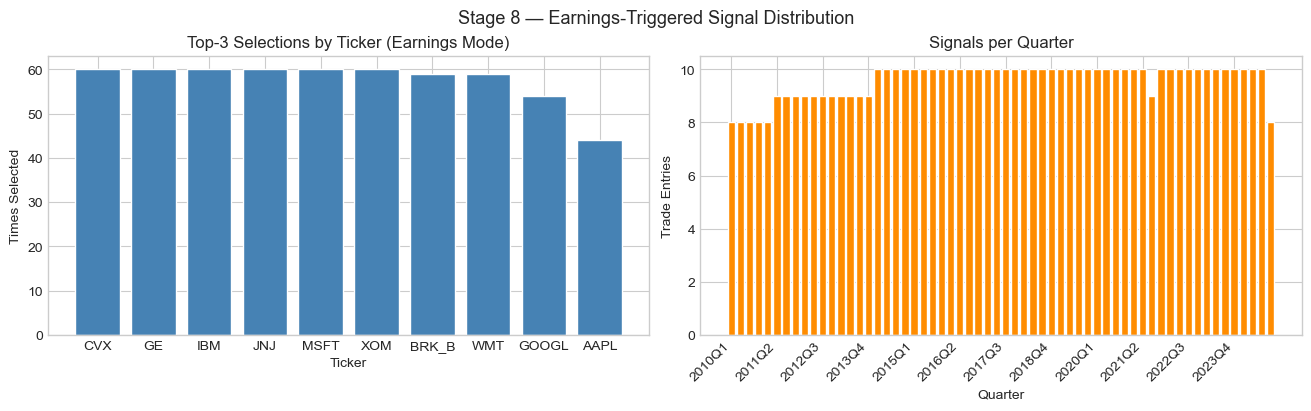

Mean prediction by rank across all earnings events:
      mean_prediction
rank                 
1             -0.0002
2             -0.0004
3             -0.0008


In [32]:
# Signal frequency diagnostics
if "top_k_df" not in globals() or top_k_df.empty:
    raise RuntimeError("top_k_df is not defined. Run Stage 8 cell first.")

diag_df = top_k_df[["ticker", "entry_date_hint", "rank", "prediction"]].copy()
diag_df["entry_date_hint"] = pd.to_datetime(diag_df["entry_date_hint"], errors="coerce")
diag_df = diag_df.dropna(subset=["ticker", "entry_date_hint"])

ticker_freq  = diag_df.groupby("ticker").size().sort_values(ascending=False)
quarter_freq = (
    diag_df.assign(quarter=diag_df["entry_date_hint"].dt.to_period("Q").astype(str))
           .groupby("quarter").size().sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)

axes[0].bar(ticker_freq.index.astype(str), ticker_freq.to_numpy(), color="steelblue", edgecolor="white")
axes[0].set_title(f"Top-{K} Selections by Ticker (Earnings Mode)", fontsize=12)
axes[0].set_xlabel("Ticker")
axes[0].set_ylabel("Times Selected")

xq = np.arange(len(quarter_freq))
axes[1].bar(xq, quarter_freq.to_numpy(), color="darkorange", edgecolor="white")
axes[1].set_title("Signals per Quarter", fontsize=12)
axes[1].set_xlabel("Quarter"); axes[1].set_ylabel("Trade Entries")
step = max(1, len(quarter_freq) // 12)
axes[1].set_xticks(xq[::step])
axes[1].set_xticklabels(quarter_freq.index[::step], rotation=45, ha="right")

fig.suptitle("Stage 8 — Earnings-Triggered Signal Distribution", fontsize=13)
plt.show()
plt.close(fig)

print("Mean prediction by rank across all earnings events:")
print(diag_df.groupby("rank", dropna=False)["prediction"].mean()
             .rename("mean_prediction").to_frame())


---
## Stage 9 — Option Selection (`src/option_selection.py`)

For each top-K stock on signal date `t`, we select the best available ATM call option
to enter on `t+1`. Selection criteria (in priority order):

1. **DTE window:** 30–45 days to expiry (relaxes to full available range if unavailable)
2. **ATM proximity:** minimize |moneyness − 1| where moneyness = S/K
3. **Liquidity proxy:** maximize open interest

Data source: `optionmetrics_calls_atm_20_60d_full_history.parquet`.

**v2 design note — DTE and IV:** Near-ATM options with 30–45 DTE provide a balance between
gamma (which decays rapidly as DTE → 0) and theta cost. Options selected too close to
expiry (< 20 DTE) are dominated by pin risk; options too far out (> 60 DTE) have low
gamma relative to their theta cost.


In [33]:
entry_table = build_entry_table(top_k_df, options_df, dte_min=30, dte_max=45)

print(f"Entry records: {len(entry_table):,}")
if not entry_table.empty:
    print(f"Date range:    {entry_table['entry_date'].min().date()} → {entry_table['entry_date'].max().date()}")
    display_cols = [
        "signal_date", "entry_date", "ticker", "rank", "prediction",
        "option_mid_entry", "delta_entry", "dte_entry", "strike",
        "underlying_entry", "implied_vol_entry",
    ]
    print("\nSample entries:")
    print(entry_table[[c for c in display_cols if c in entry_table.columns]].head(9).to_string(index=False))


[option_selection] entries built=513 | skipped=63 (no option data or end-of-series)
Entry records: 513
Date range:    2010-01-19 → 2024-11-01

Sample entries:
signal_date entry_date ticker  rank  prediction  option_mid_entry  delta_entry  dte_entry   strike  underlying_entry  implied_vol_entry
 2010-01-15 2010-01-19    IBM     1     -0.0007            2.6400       0.4577         32 135.0000          134.1400             0.2041
 2010-01-21 2010-01-22     GE     1      0.0016            0.8100       0.5327         57  16.0000           16.1100             0.3134
 2010-01-25 2010-01-26    JNJ     1      0.0012            0.4650       0.2392         53  65.0000           62.7900             0.1460
 2010-01-27 2010-01-28   MSFT     1     -0.0002            1.4150       0.5298         51  29.0000           29.1600             0.3218
 2010-01-28 2010-01-29    CVX     1      0.0004            3.4000       0.6307         50  70.0000           72.1200             0.2449
 2010-01-29 2010-02-01   

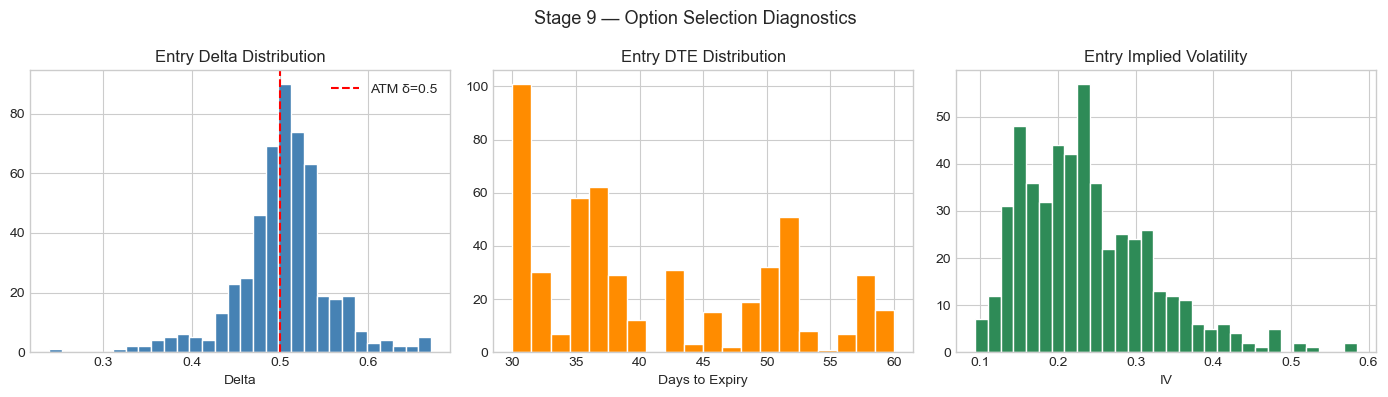

In [34]:
if not entry_table.empty:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].hist(entry_table["delta_entry"].dropna(), bins=30, color="steelblue", edgecolor="white")
    axes[0].axvline(0.5, color="red", linestyle="--", label="ATM δ=0.5")
    axes[0].set_title("Entry Delta Distribution"); axes[0].set_xlabel("Delta")
    axes[0].legend()

    axes[1].hist(entry_table["dte_entry"].dropna(), bins=20, color="darkorange", edgecolor="white")
    axes[1].set_title("Entry DTE Distribution"); axes[1].set_xlabel("Days to Expiry")

    if "implied_vol_entry" in entry_table.columns:
        axes[2].hist(entry_table["implied_vol_entry"].dropna(), bins=30, color="seagreen", edgecolor="white")
        axes[2].set_title("Entry Implied Volatility"); axes[2].set_xlabel("IV")

    plt.suptitle("Stage 9 — Option Selection Diagnostics", fontsize=13)
    plt.tight_layout(); plt.show()


---
## Stage 10 — Delta Hedge

Each long call position is delta-hedged by shorting `delta × 100` shares:

$$\text{stock\_position} = -\delta \times 100 \times n\_contracts$$

This achieves net delta ≈ 0 at entry, isolating **gamma** and **vega** as primary return drivers.

**Hedge example:** delta = 0.52, 1 contract → short 52 shares. Net delta ≈ 0.

---
## Stage 11 — Daily Rebalance

As the underlying price moves, delta changes. The hedge is rebalanced daily:

$$\Delta\text{shares} = -(\delta_{t} - \delta_{t-1}) \times 100 \times n\_contracts$$

The rebalance cost is the bid-ask spread on the adjusted shares.


In [35]:
if not entry_table.empty:
    ex = entry_table.iloc[0]
    delta = ex["delta_entry"]
    stock_pos = initial_stock_position(delta, num_contracts=1)

    print("=== Delta Hedge — Entry Example ===")
    print(f"  Ticker:         {ex['ticker']}")
    print(f"  Entry date:     {ex['entry_date'].date()}")
    print(f"  Strike:         {ex['strike']:.2f}")
    print(f"  Expiry:         {ex['expiry'].date()}")
    print(f"  Option mid:     ${ex['option_mid_entry']:.2f}")
    print(f"  Underlying:     ${ex['underlying_entry']:.2f}")
    print(f"  Delta at entry: {delta:.4f}")
    print(f"  Stock position: {stock_pos:.0f} shares (short)")
    print(f"  Option cost:    ${ex['option_mid_entry'] * CONTRACT_SIZE:.2f}")
    print(f"  Net delta:      {delta + stock_pos / CONTRACT_SIZE:.4f} ≈ 0")

    hypothetical_new_delta = delta + 0.05
    adj = hedge_adjustment(delta, hypothetical_new_delta, num_contracts=1)
    print(f"\n=== Day +1 Rebalance (hypothetical δ={hypothetical_new_delta:.2f}) ===")
    print(f"  Old stock position: {stock_pos:.0f} shares")
    print(f"  Adjustment:         {adj:.0f} shares (short {abs(adj):.0f} more)")
    print(f"  New stock position: {stock_pos + adj:.0f} shares")


=== Delta Hedge — Entry Example ===
  Ticker:         IBM
  Entry date:     2010-01-19
  Strike:         135.00
  Expiry:         2010-02-20
  Option mid:     $2.64
  Underlying:     $134.14
  Delta at entry: 0.4577
  Stock position: -46 shares (short)
  Option cost:    $264.00
  Net delta:      0.0000 ≈ 0

=== Day +1 Rebalance (hypothetical δ=0.51) ===
  Old stock position: -46 shares
  Adjustment:         -5 shares (short 5 more)
  New stock position: -51 shares


---
## Stage 12 — P&L Computation

Daily P&L for each open position has two components:

$$\text{PnL}_\text{option} = (\text{mid}_{t} - \text{mid}_{t-1}) \times 100 \times n$$
$$\text{PnL}_\text{stock} = w_\text{stock} \times (S_t - S_{t-1})$$
$$\text{PnL}_\text{total} = \text{PnL}_\text{option} + \text{PnL}_\text{stock} - \text{rebalance cost}$$

where $w_\text{stock} < 0$ (short). The strategy is long gamma: large moves in either direction
cause the option to gain more than the hedge loses.

The full backtest loop runs Stages 8–12 end-to-end.


---
## Backtest Parameters - Design Choices

### 1: Capital scaling via `num_contracts`

**Problem (v1):** `INITIAL_CAPITAL = $1,000,000` with `num_contracts` is computed to target **1% of capital per position** at entry:

$$n = \max\left(1, \left\lfloor \frac{0.01 \times \text{INITIAL\_CAPITAL}}{\text{avg\_entry\_cost} \times 100} \right\rfloor\right)$$

This keeps total option exposure ≈ K% of capital and makes return percentages economically
meaningful. The `avg_entry_cost` is estimated from the `entry_table` before the backtest runs.

---

### 2: Post-announcement entry

`max_holding_days = 20`, `earnings_cycle_mode = True`, and `top_k_df` uses
`entry_date_hint = rdq` (the announcement date) but `build_entry_table` finds the option
on the *next available option trading date* after the hint. In practice this is usually
`rdq + 1 business day`, landing after the announcement. Combined with a 20-day hold,
the strategy captures Post-Earnings Announcement Drift (PEAD) rather than betting on IV.

---

### 3: Stop-loss recalibration

Stop-loss threshold = `1.5 × estimated_daily_theta_dollar`:

$$\text{stop\_threshold} = -1.5 \times \theta_{\$/\text{day}}$$

where $\theta_{\$/\text{day}} \approx \text{option\_price} \times 100 / \text{DTE\_at\_entry}$
(a rough Black-Scholes theta approximation for ATM options). This sets the stop at 1.5 daily
theta costs — a loss that is structurally meaningful rather than arbitrary noise.

The `stop_loss_frac_of_entry_cost` parameter in `run_backtest` accepts a per-position override;
here it is computed and passed in as a scalar that is uniform across the cohort.

---

### 4: Symmetric exit with `use_signal_exit=True`

`use_signal_exit=True`. When a ticker drops out of top-K on any signal date
after entry, the position is flagged for exit on the next trading day. This enforces
symmetric discipline: both bad P&L and deteriorating rank trigger exit.

---

### 5: Delta-equivalent SPY benchmark

A **delta-equivalent SPY benchmark** is added. For each day the strategy has
open positions, it buys `net_delta_exposure / SPY_price` shares of SPY and marks them
close-to-close. This isolates alpha from market beta on the actually-deployed capital.

---

### 6: Walk-forward signal guard

an **assertion cell**
documents the assumption: every `signal_date < entry_date`. If the LSTM predictions were
re-produced by a rolling walk-forward re-train, this assertion would still hold. It exists
so that when that re-train is implemented, the assertion cell is the auditable checkpoint.


In [36]:
# ============================================================
# Run full backtest — Earnings-triggered, fast-exit + strict stop-loss
# ============================================================

INITIAL_CAPITAL = 1_000_000.0
K_BACKTEST = 2
NUM_CONTRACTS = 1
DTE_MIN, DTE_MAX = 30, 45
EXIT_DTE_THRESHOLD = 10
ENTRY_MONEYNESS_MIN = None
ENTRY_MONEYNESS_MAX = None
ENTRY_MIN_OPEN_INTEREST = None
ENTRY_MAX_SPREAD_FRAC = None

# --- Dynamic strict optimization settings ---
AUTO_OPTIMIZE_STRICT = True
STRICT_HOLD_GRID = list(range(2, 11))
STRICT_STOP_GRID = [0.05, 0.075, 0.10, 0.125, 0.15, 0.20, 0.30, 0.40]
STRICT_THRESHOLD_GRID = [0.0005, 0.0010, 0.0015, 0.0020, 0.0030]
# Option-parameter grids (set multiple values to co-optimize option settings).
# Keep singletons by default for faster runs.
STRICT_DTE_MIN_GRID = [DTE_MIN]
STRICT_DTE_MAX_GRID = [DTE_MAX]
STRICT_EXIT_DTE_GRID = [EXIT_DTE_THRESHOLD]

# Fallback defaults if auto-opt is disabled.
MAX_HOLD_BARS = 3
ENTRY_PREDICTION_THRESHOLD = 0.0010
STOP_LOSS_FRAC = 0.10

top_k_for_backtest = top_k_df[top_k_df["rank"] <= K_BACKTEST].copy()

import importlib
import src.backtest_utils as _btu
importlib.reload(_btu)

if AUTO_OPTIMIZE_STRICT:
    strict_grid_df = _btu.optimize_backtest_grid(
        predictions_df=predictions_df,
        options_df=options_df,
        K=K_BACKTEST,
        top_k_df=top_k_for_backtest,
        initial_capital=INITIAL_CAPITAL,
        hold_days_grid=STRICT_HOLD_GRID,
        stop_loss_grid=STRICT_STOP_GRID,
        entry_threshold_grid=STRICT_THRESHOLD_GRID,
        dte_min=DTE_MIN,
        dte_max=DTE_MAX,
        exit_dte_threshold=EXIT_DTE_THRESHOLD,
        entry_moneyness_min=ENTRY_MONEYNESS_MIN,
        entry_moneyness_max=ENTRY_MONEYNESS_MAX,
        entry_min_open_interest=ENTRY_MIN_OPEN_INTEREST,
        entry_max_spread_frac=ENTRY_MAX_SPREAD_FRAC,
        dte_min_grid=STRICT_DTE_MIN_GRID,
        dte_max_grid=STRICT_DTE_MAX_GRID,
        exit_dte_threshold_grid=STRICT_EXIT_DTE_GRID,
        num_contracts=NUM_CONTRACTS,
        commission_per_contract=1.0,
        half_spread_pct_stock=0.0005,
        half_spread_pct_option=0.02,
        use_signal_exit=False,
        earnings_cycle_mode=True,
        drawdown_penalty=0.25,
        suppress_run_output=True,
    )
    best_cfg = _btu.select_best_backtest_config(
        strict_grid_df,
        strict_only=True,
        max_stop_loss_frac=0.10,
        min_entry_threshold=0.0010,
        min_hold_days=2,
        max_hold_days=10,
        min_exits=20,
        min_avg_days_held=2.0,
        prefer_fast_exit=True,
        prefer_tighter_stop=True,
        prefer_higher_threshold=True,
    )
    if best_cfg is None:
        raise ValueError("No strict config met constraints. Relax strict filters.")
    MAX_HOLD_BARS = int(best_cfg["hold_days"])
    STOP_LOSS_FRAC = float(best_cfg["stop_loss_frac"])
    ENTRY_PREDICTION_THRESHOLD = float(best_cfg["entry_threshold"])
    DTE_MIN = int(best_cfg["dte_min"])
    DTE_MAX = int(best_cfg["dte_max"])
    EXIT_DTE_THRESHOLD = int(best_cfg["exit_dte_threshold"])
    strict_grid_path = ROOT / "tempfolder" / "strict_dynamic_optimization_new_predictions.csv"
    strict_grid_df.to_csv(strict_grid_path, index=False)
    print("[opt] selected strict params:")
    print({
        "MAX_HOLD_BARS": MAX_HOLD_BARS,
        "STOP_LOSS_FRAC": STOP_LOSS_FRAC,
        "ENTRY_PREDICTION_THRESHOLD": ENTRY_PREDICTION_THRESHOLD,
        "DTE_MIN": DTE_MIN,
        "DTE_MAX": DTE_MAX,
        "EXIT_DTE_THRESHOLD": EXIT_DTE_THRESHOLD,
    })
    print(f"[opt] grid saved: {strict_grid_path}")

results = _btu.run_backtest(
    predictions_df=predictions_df,
    options_df=options_df,
    K=K_BACKTEST,
    initial_capital=INITIAL_CAPITAL,
    max_holding_days=MAX_HOLD_BARS,
    exit_dte_threshold=EXIT_DTE_THRESHOLD,
    num_contracts=NUM_CONTRACTS,
    commission_per_contract=1.0,
    half_spread_pct_stock=0.0005,
    half_spread_pct_option=0.02,
    dte_min=DTE_MIN,
    dte_max=DTE_MAX,
    entry_moneyness_min=ENTRY_MONEYNESS_MIN,
    entry_moneyness_max=ENTRY_MONEYNESS_MAX,
    entry_min_open_interest=ENTRY_MIN_OPEN_INTEREST,
    entry_max_spread_frac=ENTRY_MAX_SPREAD_FRAC,
    use_signal_exit=False,
    top_k_df=top_k_for_backtest,
    entry_prediction_threshold=ENTRY_PREDICTION_THRESHOLD,
    stop_loss_frac_of_entry_cost=STOP_LOSS_FRAC,
    earnings_cycle_mode=True,
)


[opt] selected strict params:
{'MAX_HOLD_BARS': 3, 'STOP_LOSS_FRAC': 0.05, 'ENTRY_PREDICTION_THRESHOLD': 0.001, 'DTE_MIN': 30, 'DTE_MAX': 45, 'EXIT_DTE_THRESHOLD': 10}
[opt] grid saved: /Users/vidhi/Desktop/team_t/tempfolder/strict_dynamic_optimization_new_predictions.csv

[backtest] === Results ===
  Period:         2010-01-04 → 2024-12-31
  Total return:   0.62%
  Sharpe ratio:   -36.399
  Max drawdown:   -0.08%
  Hit rate:       0.72%
  Trades entered: 33
  Trades exited:  33
  Avg bars held:  2.6
  Max bars held:  3
  Note: 'bars held' are trading sessions in this backtest timeline, not calendar days.
  Exit reasons:   {'hpr_limit_exit': 17, 'stop_loss': 16}


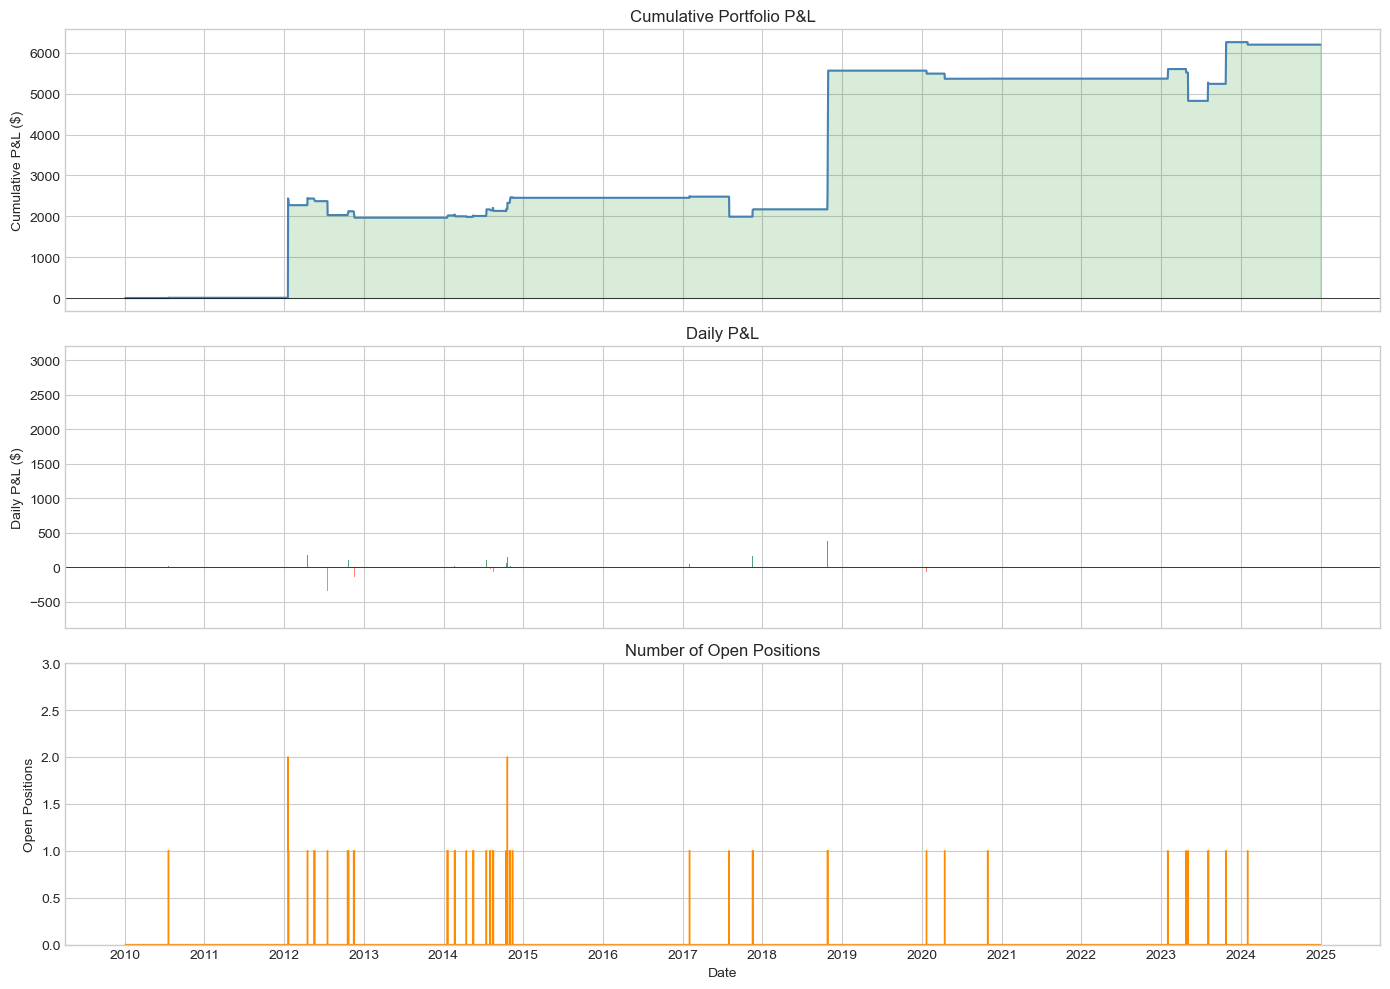


Exit reason breakdown:
exit_reason
hpr_limit_exit    17
stop_loss         16


In [37]:
# --- Daily P&L and position count over time ---
daily_df     = results["daily_pnl_df"]
trade_log    = results["trade_log"]
position_log = results["position_log"]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

cum_pnl = daily_df["daily_pnl"].cumsum()
axes[0].plot(cum_pnl.index, cum_pnl.values, color="steelblue", linewidth=1.5)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_ylabel("Cumulative P&L ($)")
axes[0].set_title("Cumulative Portfolio P&L", fontsize=12)
axes[0].fill_between(cum_pnl.index, cum_pnl.values, 0,
                     where=cum_pnl.values >= 0, alpha=0.15, color="green")
axes[0].fill_between(cum_pnl.index, cum_pnl.values, 0,
                     where=cum_pnl.values < 0, alpha=0.15, color="red")

axes[1].bar(daily_df.index, daily_df["daily_pnl"],
            color=["seagreen" if v >= 0 else "tomato" for v in daily_df["daily_pnl"]],
            width=1.5, alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_ylabel("Daily P&L ($)")
axes[1].set_title("Daily P&L", fontsize=12)

axes[2].plot(daily_df.index, daily_df["n_open_positions"],
             color="darkorange", linewidth=1, drawstyle="steps-post")
axes[2].set_ylabel("Open Positions")
axes[2].set_xlabel("Date")
axes[2].set_title("Number of Open Positions", fontsize=12)
axes[2].set_ylim(0, K_BACKTEST + 1)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout(); plt.show()

print("\nExit reason breakdown:")
if not trade_log.empty:
    exits = trade_log[trade_log["action"] == "exit"]
    print(exits["exit_reason"].value_counts().to_string())


In [38]:
# --- Export backtest results to CSV ---
os.makedirs("data/results", exist_ok=True)

cum_pnl = daily_df["daily_pnl"].cumsum().rename("cumulative_pnl")
export_daily = daily_df.join(cum_pnl)
export_daily.to_csv("data/results/daily_pnl.csv")

trade_log.to_csv("data/results/trade_log.csv", index=False)
position_log.to_csv("data/results/position_log.csv", index=False)

print("Saved:")
print(f"  data/results/daily_pnl.csv     — {len(export_daily)} rows")
print(f"  data/results/trade_log.csv     — {len(trade_log)} rows")
print(f"  data/results/position_log.csv  — {len(position_log)} rows")
print(f"  INITIAL_CAPITAL:                ${INITIAL_CAPITAL:,.0f}")
print(f"  NUM_CONTRACTS:                  {NUM_CONTRACTS}")


Saved:
  data/results/daily_pnl.csv     — 3752 rows
  data/results/trade_log.csv     — 66 rows
  data/results/position_log.csv  — 86 rows
  INITIAL_CAPITAL:                $1,000,000
  NUM_CONTRACTS:                  1


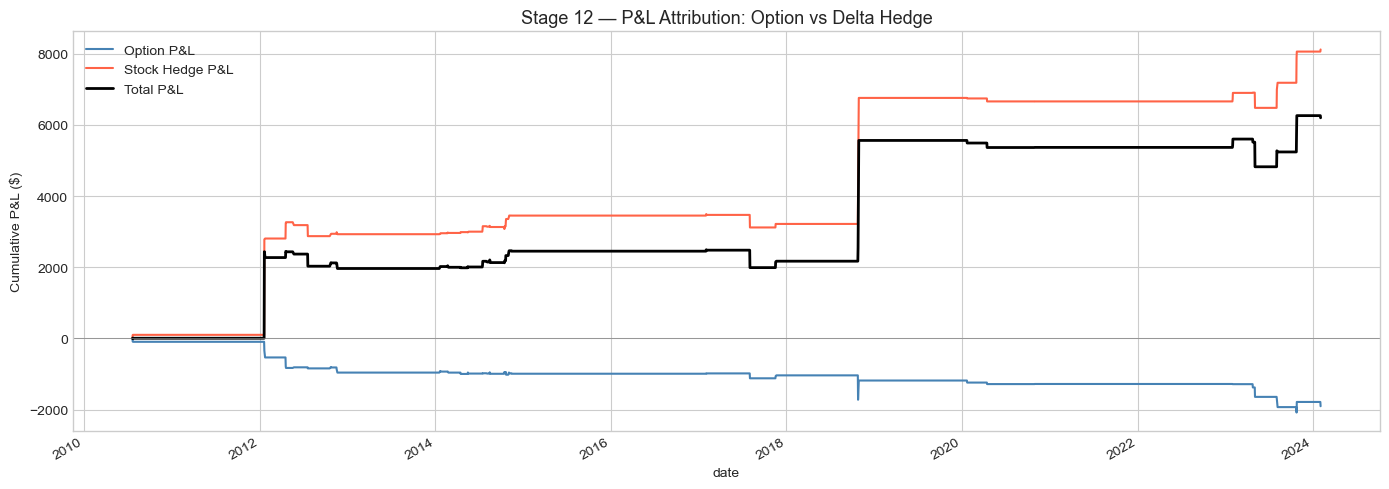

In [39]:
# --- P&L attribution: option vs stock hedge ---
if not position_log.empty:
    pos_log = pd.DataFrame(position_log) if isinstance(position_log, list) else position_log
    daily_attr = pos_log.groupby("date")[["option_pnl", "stock_pnl", "daily_pnl"]].sum()

    fig, ax = plt.subplots(figsize=(14, 5))
    daily_attr["option_pnl"].cumsum().plot(ax=ax, label="Option P&L", color="steelblue")
    daily_attr["stock_pnl"].cumsum().plot(ax=ax, label="Stock Hedge P&L", color="tomato")
    daily_attr["daily_pnl"].cumsum().plot(ax=ax, label="Total P&L", color="black", linewidth=2)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_title("Stage 12 — P&L Attribution: Option vs Delta Hedge", fontsize=13)
    ax.set_ylabel("Cumulative P&L ($)")
    ax.legend(); plt.tight_layout(); plt.show()


---
## Stage 13 - Performance Evaluation

Key metrics computed from the strategy equity curve and compared to three benchmarks:

1. **SPY Buy & Hold** — passive market benchmark on the same date window
2. **Equal-Weight Universe** — equal-weight portfolio across all prediction tickers, rebalanced daily
3. **Delta-Equivalent SPY** *(v2 addition)* — SPY position sized to match the strategy's net delta
   exposure on each day. Only active on days the strategy has open positions. This controls for
   market beta and makes the alpha attributable to option selection and earnings timing,
   not just residual directional exposure.

**note on annualisation validity:**  
The strategy's `hit_rate` and Sharpe ratio are computed over the full 2010–2024 sample.
With an earnings-triggered strategy (~4 trades/quarter × 8 tickers = ~96 trades/year),
the number of *independent observations* is much smaller than the 3,500+ calendar days.
The annualised Sharpe computed from daily returns overstates precision; interpret it alongside
the trade-level win rate and reward/risk ratio from Stage 10 as the primary edge metrics.


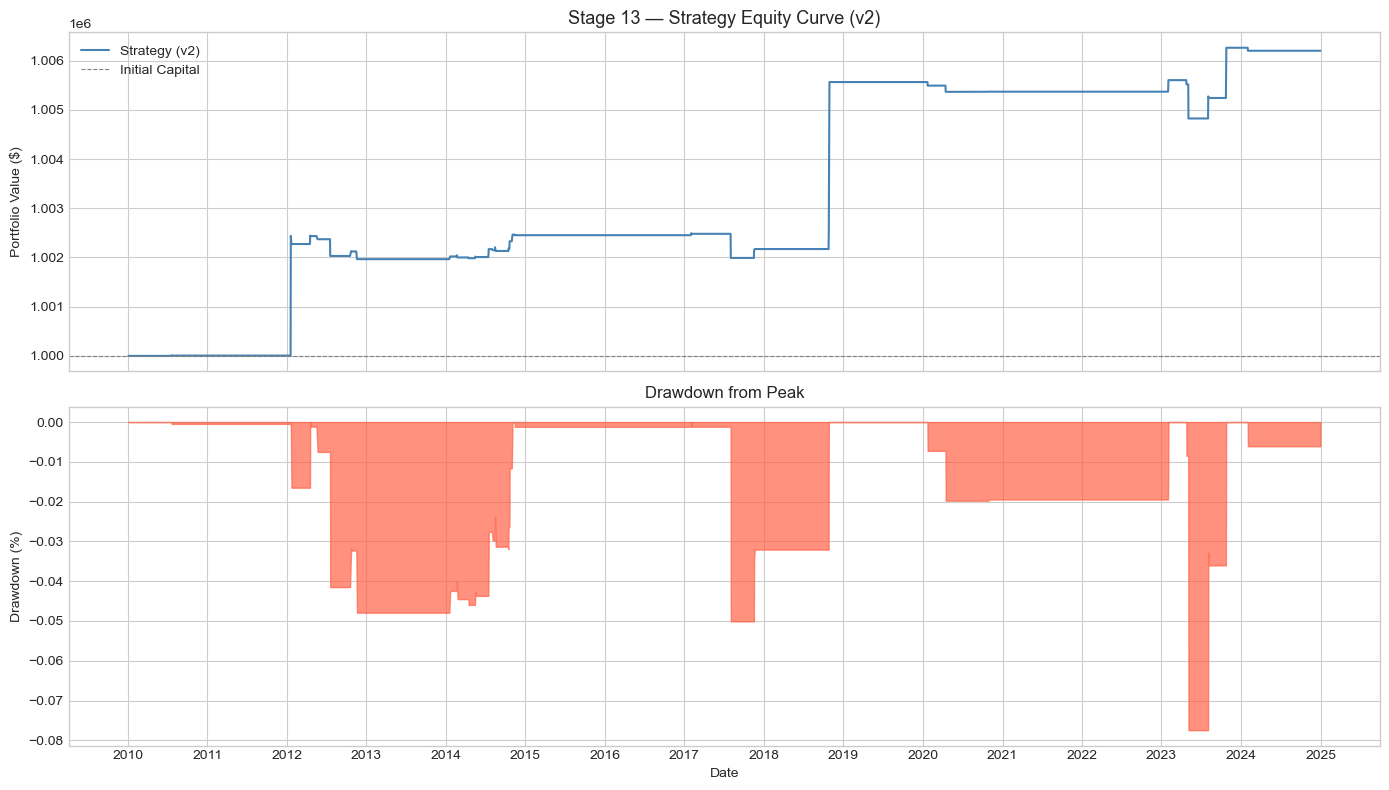

In [40]:
eq = results["equity_curve"]
dd = results["drawdown"]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(eq.index, eq.values, color="steelblue", linewidth=1.5, label="Strategy (v2)")
axes[0].axhline(INITIAL_CAPITAL, color="gray", linewidth=0.8, linestyle="--", label="Initial Capital")
axes[0].set_ylabel("Portfolio Value ($)")
axes[0].set_title("Stage 13 — Strategy Equity Curve (v2)", fontsize=13)
axes[0].legend()

axes[1].fill_between(dd.index, dd.values * 100, 0, color="tomato", alpha=0.7)
axes[1].set_ylabel("Drawdown (%)")
axes[1].set_xlabel("Date")
axes[1].set_title("Drawdown from Peak", fontsize=12)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout(); plt.show()


In [41]:
# ── Standard benchmarks (SPY + equal-weight) ──────────────────────────────
universe_tickers = sorted(predictions_df["ticker"].unique().tolist())

eval_results = evaluate_performance(
    results=results,
    prices_df=prices_df,
    universe_tickers=universe_tickers,
)

# ── Improvement 5: delta-equivalent SPY benchmark ─────────────────────────
# Build a SPY position sized daily to match the strategy's net dollar delta exposure.
# This benchmark is only "invested" on days the strategy has open positions.
_pos_log = results["position_log"] if isinstance(results["position_log"], pd.DataFrame)            else pd.DataFrame(results["position_log"])

if not _pos_log.empty and "SPY" in prices_df["ticker"].unique():
    _spy_px = (
        prices_df[prices_df["ticker"] == "SPY"]
        .set_index("date")["adj_close"]
        .sort_index()
    )
    # Net dollar delta per day: sum(delta * 100 * stock_price) across open positions
    _pos_log["date"] = pd.to_datetime(_pos_log["date"])
    _pos_log["dollar_delta"] = _pos_log["delta"] * CONTRACT_SIZE * _pos_log["stock_price"]
    _daily_delta = _pos_log.groupby("date")["dollar_delta"].sum()

    # Build delta-equivalent SPY equity curve
    _spy_ret = _spy_px.pct_change().dropna()
    _delta_eq_pnl = pd.Series(0.0, index=eq.index)
    for _date, _net_delta in _daily_delta.items():
        if _date in _spy_ret.index:
            _delta_eq_pnl[_date] = _net_delta * float(_spy_ret.loc[_date])
    _delta_spy_eq = (INITIAL_CAPITAL + _delta_eq_pnl.cumsum()).rename("delta_spy_equity")
    eval_results["benchmark_equities"]["Delta-Equivalent SPY"] = _delta_spy_eq
    print("Delta-equivalent SPY benchmark constructed.")
else:
    print("Skipping delta-equivalent SPY benchmark (position_log empty or SPY not in prices_df).")

print("\n=== Performance Table (v2) ===")
display(eval_results["performance_table"])



[evaluate_performance] === Performance Table ===
                      total_return   cagr ann_volatility   sharpe   sortino calmar max_drawdown hit_rate    n_days
Strategy                     0.62%  0.04%          0.11%  -36.399  -149.360  0.536       -0.08%    0.72% 3751.0000
SPY Buy & Hold                 N/A    N/A         17.08%    0.610     0.750    N/A      -33.70%   55.22% 3734.0000
Equal-Weight Universe          N/A    N/A         16.76%    0.679     0.857    N/A      -34.61%   54.77% 3734.0000
Delta-equivalent SPY benchmark constructed.

=== Performance Table (v2) ===


,total_return,cagr,ann_volatility,sharpe,sortino,calmar,max_drawdown,hit_rate,n_days
Strategy,0.62%,0.04%,0.11%,-36.399,-149.360,0.536,-0.08%,0.72%,3751.0000
SPY Buy & Hold,N/A,N/A,17.08%,0.610,0.750,N/A,-33.70%,55.22%,3734.0000
Equal-Weight Universe,N/A,N/A,16.76%,0.679,0.857,N/A,-34.61%,54.77%,3734.0000


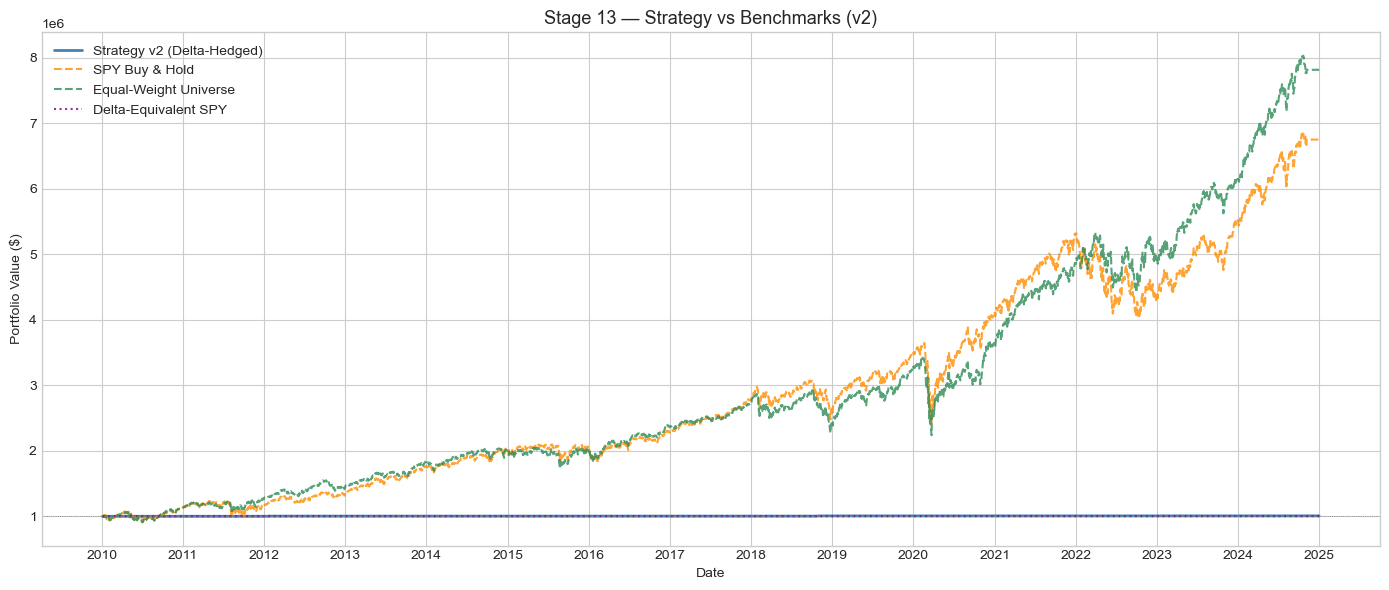

In [42]:
benchmark_equities = eval_results.get("benchmark_equities", {})

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(eq.index, eq.values, label="Strategy v2 (Delta-Hedged)", color="steelblue", linewidth=2)

_colors = {"SPY Buy & Hold": "darkorange", "Equal-Weight Universe": "seagreen",
           "Delta-Equivalent SPY": "purple"}
_styles = {"SPY Buy & Hold": "--", "Equal-Weight Universe": "--", "Delta-Equivalent SPY": ":"}
for label, bench_eq in benchmark_equities.items():
    if not bench_eq.empty:
        aligned = bench_eq.reindex(eq.index, method="ffill")
        ax.plot(aligned.index, aligned.values, label=label,
                color=_colors.get(label, "gray"),
                linestyle=_styles.get(label, "--"),
                linewidth=1.5, alpha=0.8)

ax.axhline(INITIAL_CAPITAL, color="gray", linewidth=0.6, linestyle=":")
ax.set_title("Stage 13 — Strategy vs Benchmarks (v2)", fontsize=13)
ax.set_ylabel("Portfolio Value ($)"); ax.set_xlabel("Date")
ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout(); plt.show()


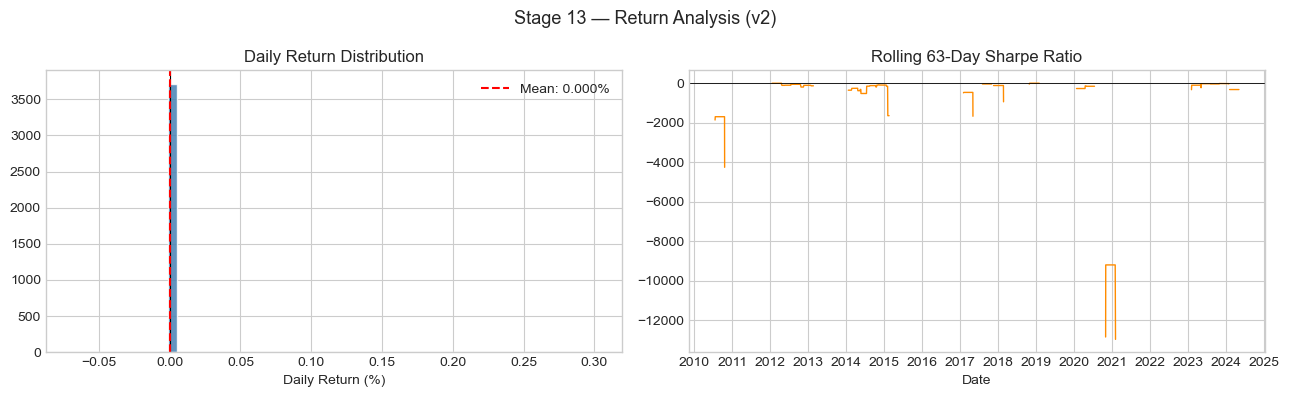


=== Strategy Metrics (v2) ===
  total_return        : 0.62%
  cagr                : 0.04%
  ann_volatility      : 0.11%
  sharpe              : -36.3989
  sortino             : -149.3597
  calmar              : 0.5363
  max_drawdown        : -0.08%
  hit_rate            : 0.72%
  n_days              : 3751

Note: Sharpe annualisation assumes i.i.d. daily returns.
With ~96 trades/year, the effective sample for inference is trade-level,
not the daily return count. See Stage 10 for trade-level edge metrics.


In [43]:
returns = eq.pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(returns * 100, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].axvline(float(returns.mean() * 100), color="red", linewidth=1.5, linestyle="--",
                label=f"Mean: {returns.mean()*100:.3f}%")
axes[0].set_title("Daily Return Distribution")
axes[0].set_xlabel("Daily Return (%)"); axes[0].legend()

# Rolling Sharpe — 63-day window (one quarter)
rf_daily = (1 + 0.04) ** (1 / 252) - 1
rolling_sharpe = (
    (returns - rf_daily).rolling(63).mean()
    / returns.rolling(63).std()
    * (252 ** 0.5)
).replace([np.inf, -np.inf], np.nan)
axes[1].plot(rolling_sharpe.index, rolling_sharpe.values, color="darkorange", linewidth=1)
axes[1].axhline(0, color="black", linewidth=0.6)
axes[1].set_title("Rolling 63-Day Sharpe Ratio")
axes[1].set_xlabel("Date")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[1].xaxis.set_major_locator(mdates.YearLocator())

plt.suptitle("Stage 13 — Return Analysis (v2)", fontsize=13)
plt.tight_layout(); plt.show()

m = results["metrics"]
print("\n=== Strategy Metrics (v2) ===")
for k, v in m.items():
    if k == "n_days":
        print(f"  {k:<20}: {int(v)}")
    elif isinstance(v, float) and not pd.isna(v):
        if k in ("total_return", "cagr", "ann_volatility", "max_drawdown", "hit_rate"):
            print(f"  {k:<20}: {v:.2%}")
        else:
            print(f"  {k:<20}: {v:.4f}")
    else:
        print(f"  {k:<20}: {v}")

print("\nNote: Sharpe annualisation assumes i.i.d. daily returns.")
print("With ~96 trades/year, the effective sample for inference is trade-level,")
print("not the daily return count. See Stage 10 for trade-level edge metrics.")


---
## Trade Log & Position Diagnostics


Total entries: 33  |  Total exits: 33

Realized P&L on exits (first 20):
      date ticker    exit_reason  days_held  realized_pnl  exit_cost
2010-07-22    JNJ hpr_limit_exit     3.0000      -30.7574     3.8350
2012-01-20   MSFT      stop_loss     2.0000      -82.1615     2.9513
2012-01-23  GOOGL hpr_limit_exit     3.0000     2344.2324    54.7229
2012-04-19    IBM hpr_limit_exit     3.0000       68.4327    11.9157
2012-05-22    WMT      stop_loss     2.0000      -63.5828     4.0868
2012-07-19    IBM      stop_loss     2.0000     -407.6099    12.8252
2012-10-24   MSFT hpr_limit_exit     3.0000       98.1062     3.2701
2012-11-19    WMT      stop_loss     3.0000     -157.8556     3.4563
2014-01-22     GE hpr_limit_exit     3.0000       55.0472     2.7258
2014-02-24    WMT      stop_loss     3.0000      -25.2358     4.3916
2014-04-16    JNJ      stop_loss     2.0000      -22.5209     6.1706
2014-05-19    WMT hpr_limit_exit     3.0000       15.8984     4.5284
2014-07-17    JNJ hpr_limit_ex

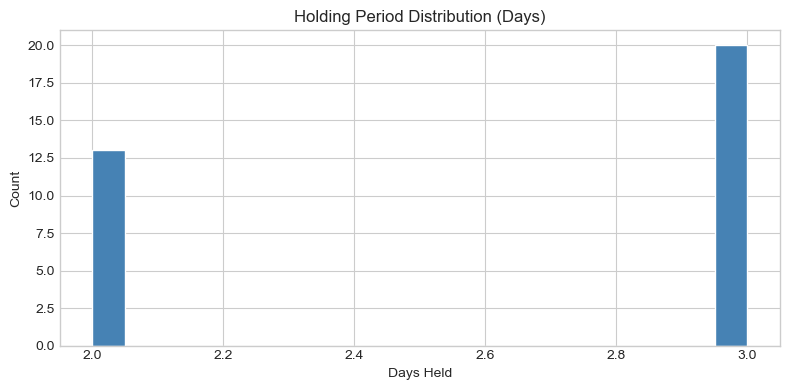

In [44]:
if not trade_log.empty:
    entries = trade_log[trade_log["action"] == "enter"].copy()
    exits   = trade_log[trade_log["action"] == "exit"].copy()

    print(f"Total entries: {len(entries)}  |  Total exits: {len(exits)}")

    if not exits.empty:
        print(f"\nRealized P&L on exits (first 20):")
        print(exits[["date", "ticker", "exit_reason", "days_held", "realized_pnl", "exit_cost"]]
              .sort_values("date").head(20).to_string(index=False))

        print(f"\nP&L by exit reason:")
        print(exits.groupby("exit_reason")["realized_pnl"].agg(["count", "sum", "mean"]).round(2))

        print(f"\nP&L by ticker:")
        print(exits.groupby("ticker")["realized_pnl"].agg(["count", "sum", "mean"]).round(2))

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.hist(exits["days_held"].dropna(), bins=20, color="steelblue", edgecolor="white")
        ax.set_title("Holding Period Distribution (Days)")
        ax.set_xlabel("Days Held"); ax.set_ylabel("Count")
        plt.tight_layout(); plt.show()


In [45]:
# ============================================================
# Full Trade Book — Every Entry, Exit, and Position Construction
# ============================================================
entries = trade_log[trade_log["action"] == "enter"].copy().reset_index(drop=True)
exits   = trade_log[trade_log["action"] == "exit"].copy().reset_index(drop=True)

exit_lookup = {}
for _, ex in exits.iterrows():
    key = (ex["ticker"], ex.get("entry_date", ex["date"]))
    exit_lookup[key] = ex

rows = []
for _, en in entries.iterrows():
    ticker     = en["ticker"]
    entry_date = en["date"]
    strike     = en.get("strike", float("nan"))
    expiry     = en.get("expiry", pd.NaT)
    dte        = en.get("dte", float("nan"))
    entry_opt  = en.get("option_price", float("nan"))
    entry_stk  = en.get("stock_price", float("nan"))
    delta      = en.get("delta", float("nan"))
    stock_pos  = en.get("stock_position", float("nan"))
    rank       = en.get("rank", float("nan"))
    pred       = en.get("prediction", float("nan"))
    entry_cost = en.get("entry_cost", float("nan"))

    hedge_shares = abs(stock_pos) if not pd.isna(stock_pos) else float("nan")
    construction = (
        f"Long {NUM_CONTRACTS}c  K={strike:.0f}"
        f"  exp={pd.Timestamp(expiry).date() if pd.notna(expiry) else 'n/a'}"
        f"  DTE={int(dte) if not pd.isna(dte) else 'n/a'}"
        f"  | Short {hedge_shares:.0f}sh @ ${entry_stk:.2f}  (δ={delta:.3f})"
        if not pd.isna(strike) else "n/a"
    )

    ex_row = exit_lookup.get((ticker, entry_date), None)
    if ex_row is not None:
        exit_date    = ex_row["date"]
        exit_reason  = ex_row.get("exit_reason", "")
        days_held    = ex_row.get("days_held", float("nan"))
        realized_pnl = ex_row.get("realized_pnl", float("nan"))
        exit_cost_v  = ex_row.get("exit_cost", float("nan"))
    else:
        exit_date = exit_reason = pd.NaT
        days_held = realized_pnl = exit_cost_v = float("nan")

    rows.append({
        "signal_date":    en.get("signal_date", pd.NaT),
        "entry_date":     entry_date,
        "exit_date":      exit_date,
        "ticker":         ticker,
        "rank":           rank,
        "prediction":     round(pred, 5) if not pd.isna(pred) else float("nan"),
        "strike":         strike,
        "expiry":         pd.Timestamp(expiry).date() if pd.notna(expiry) else pd.NaT,
        "dte_entry":      int(dte) if not pd.isna(dte) else float("nan"),
        "delta_entry":    round(delta, 3) if not pd.isna(delta) else float("nan"),
        "n_contracts":    NUM_CONTRACTS,
        "entry_opt_$":    round(entry_opt, 2) if not pd.isna(entry_opt) else float("nan"),
        "entry_stk_$":    round(entry_stk, 2) if not pd.isna(entry_stk) else float("nan"),
        "stock_pos":      int(stock_pos * NUM_CONTRACTS) if not pd.isna(stock_pos) else float("nan"),
        "entry_cost_$":   round(entry_cost, 2) if not pd.isna(entry_cost) else float("nan"),
        "days_held":      int(days_held) if not pd.isna(days_held) else float("nan"),
        "exit_reason":    exit_reason,
        "exit_cost_$":    round(exit_cost_v, 2) if not pd.isna(exit_cost_v) else float("nan"),
        "realized_pnl_$": round(realized_pnl, 2) if not pd.isna(realized_pnl) else float("nan"),
        "construction":   construction,
    })

trade_book = pd.DataFrame(rows).sort_values("entry_date").reset_index(drop=True)

print(f"Total trades: {len(trade_book)}  |  "
      f"Closed: {trade_book['exit_date'].notna().sum()}  |  "
      f"Open/unmatched: {trade_book['exit_date'].isna().sum()}")
print(f"Total realized P&L: ${trade_book['realized_pnl_$'].sum():,.2f}")
print(f"Win rate: {(trade_book['realized_pnl_$'] > 0).mean():.1%}")
print()

display_cols = [
    "entry_date", "exit_date", "ticker", "rank", "prediction",
    "strike", "expiry", "dte_entry", "delta_entry", "n_contracts",
    "entry_opt_$", "entry_stk_$", "stock_pos", "entry_cost_$",
    "days_held", "exit_reason", "exit_cost_$", "realized_pnl_$",
]
display(trade_book[display_cols].style
    .format(na_rep="—")
    .applymap(lambda v: "color: green" if isinstance(v, (int, float)) and v > 0 else
                        ("color: red" if isinstance(v, (int, float)) and v < 0 else ""),
              subset=["realized_pnl_$"])
    .set_caption(f"Full Trade Book — {NUM_CONTRACTS} contract(s) per position"))

print("\n=== Position Construction Detail (first 20) ===")
for _, r in trade_book.head(20).iterrows():
    pnl_str = f"  →  PnL: ${r['realized_pnl_$']:+.2f}" if not pd.isna(r["realized_pnl_$"]) else "  →  (open)"
    print(f"  [{r['entry_date'].date() if pd.notna(r['entry_date']) else 'n/a'}] "
          f"{r['ticker']:<6}  {r['construction']}{pnl_str}")


Total trades: 33  |  Closed: 0  |  Open/unmatched: 33
Total realized P&L: $0.00
Win rate: 0.0%



,entry_date,exit_date,ticker,rank,prediction,strike,expiry,dte_entry,delta_entry,n_contracts,entry_opt_$,entry_stk_$,stock_pos,entry_cost_$,days_held,exit_reason,exit_cost_$,realized_pnl_$
0,2010-07-20 00:00:00,—,JNJ,1.000000,0.001090,57.500000,2010-08-21,32,0.662000,1,1.750000,58.580000,-66,175.500000,—,—,—,—
1,2012-01-19 00:00:00,—,MSFT,1.000000,0.001130,28.000000,2012-02-18,30,0.540000,1,0.740000,28.120000,-54,75.500000,—,—,—,—
2,2012-01-19 00:00:00,—,GOOGL,2.000000,0.001060,640.000000,2012-02-18,30,0.517000,1,23.500000,639.570000,-51,2351.000000,—,—,—,—
3,2012-04-17 00:00:00,—,IBM,1.000000,0.001290,205.000000,2012-05-19,32,0.583000,1,6.050000,207.450000,-58,606.000000,—,—,—,—
4,2012-05-17 00:00:00,—,WMT,1.000000,0.001340,62.500000,2012-06-16,30,0.396000,1,0.770000,61.680000,-39,78.000000,—,—,—,—
5,2012-07-18 00:00:00,—,IBM,1.000000,0.001450,190.000000,2012-08-18,31,0.437000,1,3.700000,188.250000,-43,371.000000,—,—,—,—
6,2012-10-18 00:00:00,—,MSFT,1.000000,0.001180,30.000000,2012-11-17,30,0.409000,1,0.550000,29.500000,-40,55.500000,—,—,—,—
7,2012-11-15 00:00:00,—,WMT,1.000000,0.001060,67.500000,2012-12-22,37,0.637000,1,2.070000,68.720000,-63,208.000000,—,—,—,—
8,2014-01-17 00:00:00,—,GE,1.000000,0.001540,27.000000,2014-02-22,36,0.332000,1,0.260000,26.580000,-33,26.500000,—,—,—,—
9,2014-02-20 00:00:00,—,WMT,1.000000,0.002220,73.500000,2014-03-28,36,0.488000,1,1.150000,73.520000,-48,116.500000,—,—,—,—



=== Position Construction Detail (first 20) ===
  [2010-07-20] JNJ     Long 1c  K=58  exp=2010-08-21  DTE=32  | Short 66sh @ $58.58  (δ=0.662)  →  (open)
  [2012-01-19] MSFT    Long 1c  K=28  exp=2012-02-18  DTE=30  | Short 54sh @ $28.12  (δ=0.540)  →  (open)
  [2012-01-19] GOOGL   Long 1c  K=640  exp=2012-02-18  DTE=30  | Short 52sh @ $639.57  (δ=0.517)  →  (open)
  [2012-04-17] IBM     Long 1c  K=205  exp=2012-05-19  DTE=32  | Short 58sh @ $207.45  (δ=0.583)  →  (open)
  [2012-05-17] WMT     Long 1c  K=62  exp=2012-06-16  DTE=30  | Short 40sh @ $61.68  (δ=0.396)  →  (open)
  [2012-07-18] IBM     Long 1c  K=190  exp=2012-08-18  DTE=31  | Short 44sh @ $188.25  (δ=0.437)  →  (open)
  [2012-10-18] MSFT    Long 1c  K=30  exp=2012-11-17  DTE=30  | Short 41sh @ $29.50  (δ=0.409)  →  (open)
  [2012-11-15] WMT     Long 1c  K=68  exp=2012-12-22  DTE=37  | Short 64sh @ $68.72  (δ=0.637)  →  (open)
  [2014-01-17] GE      Long 1c  K=27  exp=2014-02-22  DTE=36  | Short 33sh @ $26.58  (δ=0.332)  →

---
## Stage 10 — Risk Management Framework

**Purpose:** Portfolio risk controls and exposure monitoring from realized backtest positions.
All metrics are derived from `trade_log`, `position_log`, and `daily_pnl_df` — never from
raw signals. This ensures risk figures reflect actual executed trades.

**Metrics computed:**
- Max drawdown, drawdown series, start / recovery date and duration, N distinct periods
- Rolling 21-day Sharpe, Sortino, and realized volatility (inf-safe)
- Historical VaR and CVaR (Expected Shortfall) at 0.1%, 1%, 5%, 10% confidence levels
- Gross vs net dollar exposure and net delta exposure (from position_log or trade_log reconstruction)
- Portfolio beta to SPY (delta-weighted; pass `beta_lookup` for per-ticker betas)
- Concentration: HHI and max single-ticker weight
- Trade-level: win rate, reward/risk ratio, exit reason breakdown, holding period distribution
- Drawdown-triggered (−10%) and volatility-spike (2× rolling median) de-risking event log

**Risk considerations addressed (from project risk analysis):**
drawdown analysis, CVaR/ES, Sortino decomposition, gross vs net exposure,
portfolio beta, concentration (HHI), stop-loss calibration, holding period diagnostics,
drawdown-triggered de-risking events, and annualisation validity caveats.


[Stage 10] Using live results dict from run_backtest.
[Stage 10] Equity curve built from daily_pnl_df: 3752 days, initial=$1,000,000

[Stage 10] === Risk Summary ===
  Exposure source:        position_log
  Max drawdown:           -0.08%
  Max drawdown date:      2023-05-05 00:00:00
  Recovery date:          2023-10-25 00:00:00
  Recovery days:          173
  N drawdown periods:     0
  Median rolling Sharpe:  -93.839
  Median rolling vol:     0.000
  VaR 1% (daily):         0.0000%
  CVaR 1% (daily):        -0.0001%
  Win rate:               48.48%
  Reward/risk ratio:      3.466
  Stop-loss rate:         48.48%
  Total realized PnL:     $5,910.01
  Peak gross exposure:    $64,383
  N risk events flagged:  53
  risk_exposure_daily.csv  (3752 rows)
  risk_events.csv          (53 rows)
  stress_scenarios.csv     (6 rows)

STAGE 10 — RISK SUMMARY (v2)

── Drawdown Statistics ──
  Max drawdown:           -0.08%
  Max drawdown date:      2023-05-05 00:00:00
  Drawdown started:       2023-0

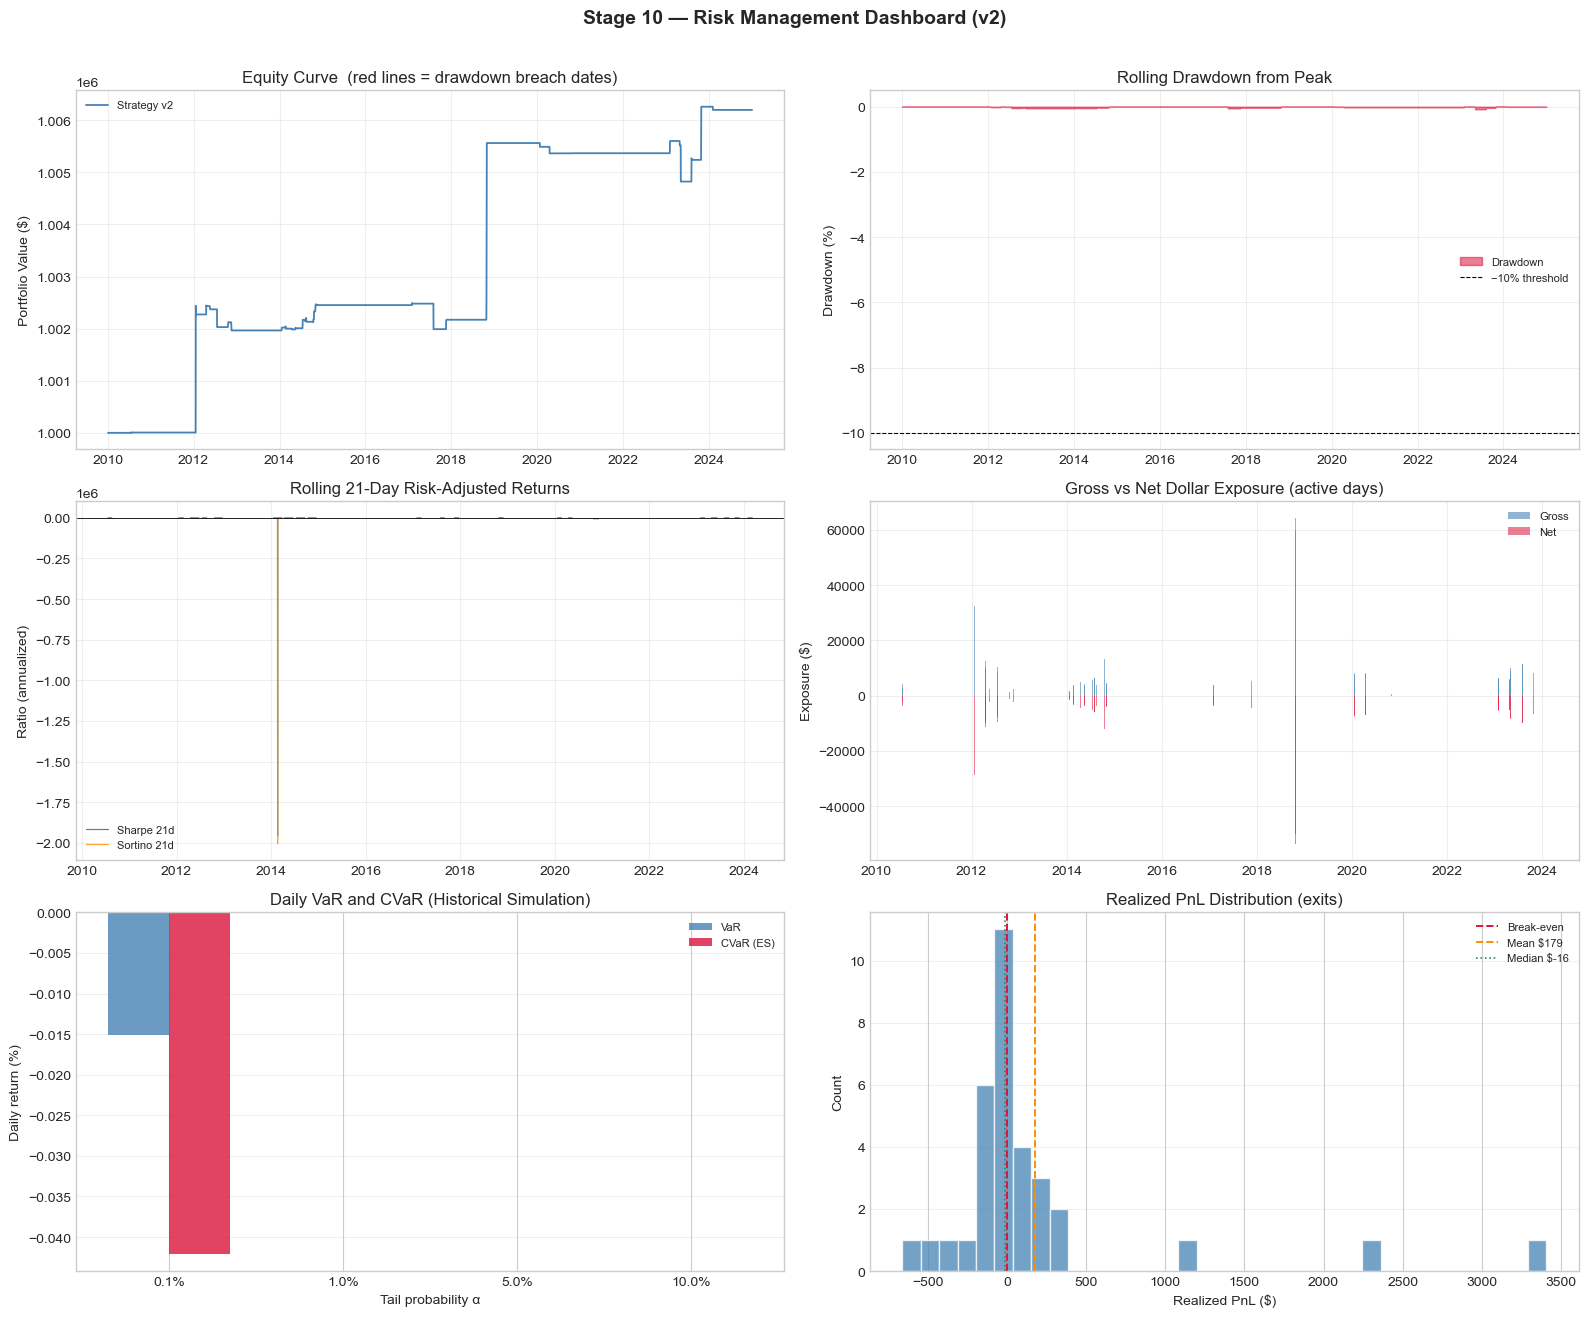


[Stage 10] Output files:
  /Users/vidhi/Desktop/team_t/notebooks/data/results/risk_exposure_daily.csv
  /Users/vidhi/Desktop/team_t/notebooks/data/results/risk_events.csv
  /Users/vidhi/Desktop/team_t/notebooks/data/results/stress_scenarios.csv


In [ ]:
importlib.reload(src.risk_utils); importlib.reload(src.exposure_utils)
from src.risk_utils import compute_all_risk_metrics
from src.exposure_utils import run_stage10, build_risk_exposure_daily

_nb_dir       = Path(".").resolve()
RESULTS_DIR   = str(_nb_dir / "data" / "results")
TRADE_LOG_PATH    = str(_nb_dir / "data" / "results" / "trade_log.csv")
POSITION_LOG_PATH = str(_nb_dir / "data" / "results" / "position_log.csv")
DAILY_PNL_PATH    = str(_nb_dir / "data" / "results" / "daily_pnl.csv")

if "results" in dir() and results is not None:
    print("[Stage 10] Using live results dict from run_backtest.")
    _equity       = results["equity_curve"]
    _position_log = (results["position_log"]
                     if isinstance(results["position_log"], pd.DataFrame)
                     else pd.DataFrame(results["position_log"]))
    _trade_log    = (results["trade_log"]
                     if isinstance(results["trade_log"], pd.DataFrame)
                     else pd.DataFrame(results["trade_log"]))
    _daily_pnl    = results["daily_pnl_df"].reset_index() if "daily_pnl_df" in results else None

    _raw = compute_all_risk_metrics(
        trade_log=_trade_log,
        position_log=_position_log if not _position_log.empty else None,
        daily_pnl_df=_daily_pnl,
        beta_lookup=None,            # swap in {ticker: beta} when available
        sector_lookup=None,          # swap in {ticker: sector} when available
        initial_capital=INITIAL_CAPITAL,
        drawdown_threshold=-0.10,
        max_gross_exposure_pct=0.10,
        max_net_exposure_pct=0.05,
        max_abs_beta_exposure=0.25,
        max_single_name_weight=0.50,
        max_sector_weight=0.60,
    )
    _risk_exp_df = build_risk_exposure_daily(_raw)

    os.makedirs(RESULTS_DIR, exist_ok=True)
    _risk_exp_path = os.path.join(RESULTS_DIR, "risk_exposure_daily.csv")
    _risk_evt_path = os.path.join(RESULTS_DIR, "risk_events.csv")
    _stress_path = os.path.join(RESULTS_DIR, "stress_scenarios.csv")
    _risk_exp_df.to_csv(_risk_exp_path, index=False)
    _raw["risk_events"].to_csv(_risk_evt_path, index=False)
    _raw["stress_table"].to_csv(_stress_path, index=False)
    print(f"  risk_exposure_daily.csv  ({len(_risk_exp_df)} rows)")
    print(f"  risk_events.csv          ({len(_raw['risk_events'])} rows)")
    print(f"  stress_scenarios.csv     ({len(_raw['stress_table'])} rows)")

    stage10 = {
        "risk_exposure_daily": _risk_exp_df,
        "risk_events":         _raw["risk_events"],
        "trade_risk_stats":    _raw["trade_risk_stats"],
        "var_cvar_table":      _raw["var_cvar_table"],
        "drawdown_stats":      _raw["drawdown_stats"],
        "stress_table":        _raw["stress_table"],
        "paths": {
            "risk_exposure_path": _risk_exp_path,
            "risk_events_path":   _risk_evt_path,
            "stress_path":        _stress_path,
        }
    }
else:
    print("[Stage 10] 'results' not in scope — loading from saved CSVs.")
    stage10 = run_stage10(
        trade_log_path=TRADE_LOG_PATH,
        position_log_path=POSITION_LOG_PATH if os.path.exists(POSITION_LOG_PATH) else None,
        daily_pnl_path=DAILY_PNL_PATH       if os.path.exists(DAILY_PNL_PATH)    else None,
        output_dir=RESULTS_DIR,
        beta_lookup=None,
        sector_lookup=None,
        initial_capital=INITIAL_CAPITAL if "INITIAL_CAPITAL" in dir() else 1_000_000.0,
        drawdown_threshold=-0.10,
        max_gross_exposure_pct=0.10,
        max_net_exposure_pct=0.05,
        max_abs_beta_exposure=0.25,
        max_single_name_weight=0.50,
        max_sector_weight=0.60,
    )

risk_exp    = stage10["risk_exposure_daily"]
risk_evts   = stage10["risk_events"]
var_tbl     = stage10["var_cvar_table"]
dd_stats    = stage10["drawdown_stats"]
trade_stats = stage10["trade_risk_stats"]
stress_tbl  = stage10.get("stress_table", pd.DataFrame())
dd_series   = dd_stats["drawdown_series"]

# ── Printed risk summary ─────────────────────────────────────────────────────
print("\n" + "=" * 64)
print("STAGE 10 — RISK SUMMARY (v2)")
print("=" * 64)

print("\n── Drawdown Statistics ──")
print(f"  Max drawdown:           {dd_stats['max_drawdown']:.2%}")
print(f"  Max drawdown date:      {dd_stats['max_drawdown_date']}")
print(f"  Drawdown started:       {dd_stats['drawdown_start_date']}")
print(f"  Recovery date:          {dd_stats['recovery_date'] or 'Not recovered in sample'}")
print(f"  Recovery days:          {dd_stats['recovery_days'] or 'N/A'}")
print(f"  N distinct DD periods:  {dd_stats['n_drawdown_periods']}")

print("\n── VaR and CVaR (Historical Simulation — daily returns) ──")
vc = var_tbl.copy()
vc["confidence_level"] = vc["confidence_level"].map(lambda x: f"{x:.1%}")
vc["var_pct"]    = vc["var_pct"].map(lambda x: f"{x:.4%}")
vc["cvar_pct"]   = vc["cvar_pct"].map(lambda x: f"{x:.4%}")
vc["var_dollar"]  = vc["var_dollar"].map(lambda x: f"${x:,.0f}")
vc["cvar_dollar"] = vc["cvar_dollar"].map(lambda x: f"${x:,.0f}")
print(vc.to_string(index=False))

print("\n── Rolling Risk (21-day window) ──")
if "rolling_sharpe_21d" in risk_exp.columns:
    rs = risk_exp["rolling_sharpe_21d"].replace([np.inf, -np.inf], np.nan).dropna()
    rv = risk_exp["rolling_vol_21d"].replace([np.inf, -np.inf], np.nan).dropna()
    so = risk_exp["rolling_sortino_21d"].replace([np.inf, -np.inf], np.nan).dropna()
    print(f"  Median Sharpe  (21d):   {rs.median():.3f}")
    print(f"  Median Sortino (21d):   {so.median():.3f}")
    print(f"  Median Ann. Vol:        {rv.median():.3f}")

print("\n── Exposure & Concentration ──")
exp_active = risk_exp[risk_exp["n_positions"].fillna(0) > 0]
if not exp_active.empty and "gross_exposure" in exp_active.columns:
    print(f"  Days with open positions: {len(exp_active)}")
    print(f"  Peak gross exposure:      ${exp_active['gross_exposure'].max():,.0f}")
    print(f"  Avg net exposure:         ${exp_active['net_exposure'].mean():,.0f}")
if "hhi" in exp_active.columns:
    print(f"  Avg HHI:                  {exp_active['hhi'].mean():.3f}  (1.0 = single position)")
    print(f"  Max single-ticker weight: {exp_active['max_weight_pct'].max():.1%}")
if "net_beta_exposure" in exp_active.columns:
    print(f"  Avg net beta to SPY:      {exp_active['net_beta_exposure'].mean():.3f}")

print("\n── Trade Risk Diagnostics ──")
ts = trade_stats
print(f"  N entries / exits:      {ts['n_entries']} / {ts['n_exits']}")
print(f"  Win rate:               {ts['win_rate']:.2%}")
print(f"  Avg win PnL:            ${ts['avg_win_pnl']:,.2f}")
print(f"  Avg loss PnL:           ${ts['avg_loss_pnl']:,.2f}")
print(f"  Total realized PnL:     ${ts['total_realized_pnl']:,.2f}")
rr = ts["reward_risk_ratio"]
print(f"  Reward/risk ratio:      {rr:.3f}" if not (isinstance(rr, float) and rr != rr) else "  Reward/risk ratio:      N/A")
print(f"  Stop-loss rate:         {ts['stop_loss_rate']:.2%}  ({ts['n_stop_loss']} trades)")
print(f"  Exit reasons:           {ts['exit_reason_counts']}")
print(f"  Avg days held:          {ts['avg_days_held']:.1f}")
print(f"  P25/P50/P75 days:       {ts['p25_days_held']:.0f} / {ts['p50_days_held']:.0f} / {ts['p75_days_held']:.0f}")
print(f"  Avg entry cost:         ${ts['avg_entry_cost']:,.2f}")

print("\n── Marked Exposure Limits ──")
for _col, _label in [
    ("gross_exposure_pct_equity", "Peak gross / equity"),
    ("net_exposure_pct_equity",   "Peak |net| / equity"),
    ("net_beta_exposure_pct_equity", "Peak |beta| / equity"),
]:
    if _col in risk_exp.columns:
        print(f"  {_label:<24}: {risk_exp[_col].max():.2%}")
for _flag, _label in [
    ("gross_exposure_limit_breach", "Gross exposure breaches"),
    ("net_exposure_limit_breach",   "Net exposure breaches"),
    ("beta_limit_breach",           "Beta exposure breaches"),
    ("single_name_limit_breach",    "Single-name breaches"),
    ("sector_limit_breach",         "Sector breaches"),
]:
    if _flag in risk_exp.columns:
        print(f"  {_label:<24}: {int(risk_exp[_flag].fillna(False).sum())}")

if not stress_tbl.empty:
    print("\n── Stress Scenarios (latest marked book) ──")
    print(stress_tbl.to_string(index=False))

if not risk_evts.empty:
    n_dd  = (risk_evts["trigger_type"] == "drawdown_breach").sum()
    n_vol = (risk_evts["trigger_type"] == "volatility_spike").sum()
    print(f"\n── Risk Events ({len(risk_evts)} total: {n_dd} drawdown breaches, {n_vol} vol spikes) ──")
    print(risk_evts[["date", "trigger_type", "value", "description"]].head(10).to_string(index=False))

# ── 6-panel risk dashboard ────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 13))
fig.suptitle("Stage 10 — Risk Management Dashboard (v2)", fontsize=14, fontweight="bold", y=1.01)

risk_exp["date"] = pd.to_datetime(risk_exp["date"])
_dates = risk_exp["date"]
_eq    = risk_exp["equity"]
_dd    = (dd_series.reindex(risk_exp["date"]).fillna(0)
          if hasattr(dd_series, "reindex")
          else risk_exp.get("drawdown", pd.Series(0.0, index=risk_exp.index)).fillna(0))

# Panel 1 — Equity + drawdown breach markers
ax = axes[0, 0]
ax.plot(_dates, _eq, color="steelblue", linewidth=1.3, label="Strategy v2")
if not risk_evts.empty:
    for _, row in risk_evts[risk_evts["trigger_type"] == "drawdown_breach"].iterrows():
        ax.axvline(pd.to_datetime(row["date"]), color="crimson", alpha=0.35, linewidth=0.8)
ax.set_title("Equity Curve  (red lines = drawdown breach dates)")
ax.set_ylabel("Portfolio Value ($)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Panel 2 — Drawdown
ax = axes[0, 1]
ax.fill_between(_dates, _dd * 100, 0, color="crimson", alpha=0.55, label="Drawdown")
ax.axhline(-10, color="black", linestyle="--", linewidth=0.8, label="−10% threshold")
ax.set_title("Rolling Drawdown from Peak")
ax.set_ylabel("Drawdown (%)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Panel 3 — Rolling Sharpe & Sortino
ax = axes[1, 0]
if "rolling_sharpe_21d" in risk_exp.columns:
    _rs = risk_exp.set_index("date")["rolling_sharpe_21d"].replace([np.inf, -np.inf], np.nan)
    _so = risk_exp.set_index("date")["rolling_sortino_21d"].replace([np.inf, -np.inf], np.nan)
    ax.plot(_rs.index, _rs, color="steelblue", linewidth=0.85, label="Sharpe 21d")
    ax.plot(_so.index, _so, color="darkorange", linewidth=0.85, alpha=0.8, label="Sortino 21d")
    ax.axhline(0, color="black", linewidth=0.6)
ax.set_title("Rolling 21-Day Risk-Adjusted Returns")
ax.set_ylabel("Ratio (annualized)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Panel 4 — Gross vs Net Exposure
ax = axes[1, 1]
_exp_a = risk_exp[risk_exp["n_positions"].fillna(0) > 0].copy()
if not _exp_a.empty and "gross_exposure" in _exp_a.columns:
    ax.bar(_exp_a["date"], _exp_a["gross_exposure"], color="steelblue", alpha=0.6, width=4, label="Gross")
    ax.bar(_exp_a["date"], _exp_a["net_exposure"],   color="crimson",   alpha=0.55, width=4, label="Net")
ax.set_title("Gross vs Net Dollar Exposure (active days)")
ax.set_ylabel("Exposure ($)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Panel 5 — VaR / CVaR
ax = axes[2, 0]
_raw_vc = stage10["var_cvar_table"]
_labels = _raw_vc["confidence_level"].map(lambda x: f"{x:.1%}").tolist()
_x = np.arange(len(_labels)); _w = 0.35
ax.bar(_x - _w/2, _raw_vc["var_pct"]  * 100, _w, color="steelblue", alpha=0.8, label="VaR")
ax.bar(_x + _w/2, _raw_vc["cvar_pct"] * 100, _w, color="crimson",   alpha=0.8, label="CVaR (ES)")
ax.set_xticks(_x); ax.set_xticklabels(_labels)
ax.set_title("Daily VaR and CVaR (Historical Simulation)")
ax.set_ylabel("Daily return (%)"); ax.set_xlabel("Tail probability α")
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")

# Panel 6 — Realized PnL distribution
ax = axes[2, 1]
_exits_pl = (_trade_log[_trade_log["action"] == "exit"]["realized_pnl"].dropna()
             if ("_trade_log" in dir() and not _trade_log.empty)
             else pd.Series(dtype=float))
if _exits_pl.empty and os.path.exists(TRADE_LOG_PATH):
    _exits_pl = pd.read_csv(TRADE_LOG_PATH)
    _exits_pl = _exits_pl[_exits_pl["action"] == "exit"]["realized_pnl"].dropna()
if not _exits_pl.empty:
    ax.hist(_exits_pl, bins=35, color="steelblue", alpha=0.75, edgecolor="white")
    ax.axvline(0,                   color="crimson",    linewidth=1.4, linestyle="--", label="Break-even")
    ax.axvline(_exits_pl.mean(),    color="darkorange", linewidth=1.4, linestyle="--",
               label=f"Mean ${_exits_pl.mean():,.0f}")
    ax.axvline(_exits_pl.median(),  color="seagreen",   linewidth=1.2, linestyle=":",
               label=f"Median ${_exits_pl.median():,.0f}")
ax.set_title("Realized PnL Distribution (exits)")
ax.set_xlabel("Realized PnL ($)"); ax.set_ylabel("Count")
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
_fig_dir = _nb_dir / "docs" / "figures"
_fig_dir.mkdir(parents=True, exist_ok=True)
try:
    plt.savefig(str(_fig_dir / "stage10_risk_dashboard_v2.png"), dpi=120, bbox_inches="tight")
    print(f"\n[Stage 10] Dashboard saved → docs/figures/stage10_risk_dashboard_v2.png")
except Exception as _e:
    print(f"[Stage 10] Figure save skipped: {_e}")
plt.show()

print("\n[Stage 10] Output files:")
print(f"  {stage10['paths']['risk_exposure_path']}")
print(f"  {stage10['paths']['risk_events_path']}")
if "stress_path" in stage10["paths"]:
    print(f"  {stage10['paths']['stress_path']}")
